==== Fit target: CE Moving Average (cm) ====
Dropped first 30 days starting from: 2022-09-01 19:30:00+00:00
dP used: z-scored (Pn-Pe)

-- No-season model: y = C + a*dP  | R^2 = 0.9151
   C  :  164214.320859
   a  : -7.033305

-- Seasonal model: y = C + a*dP + b*sin + c*cos  | R^2 = 0.9497
   C  :  164214.424479
   a  : -7.338578
   b  : -0.002839
   c  :  2.022609


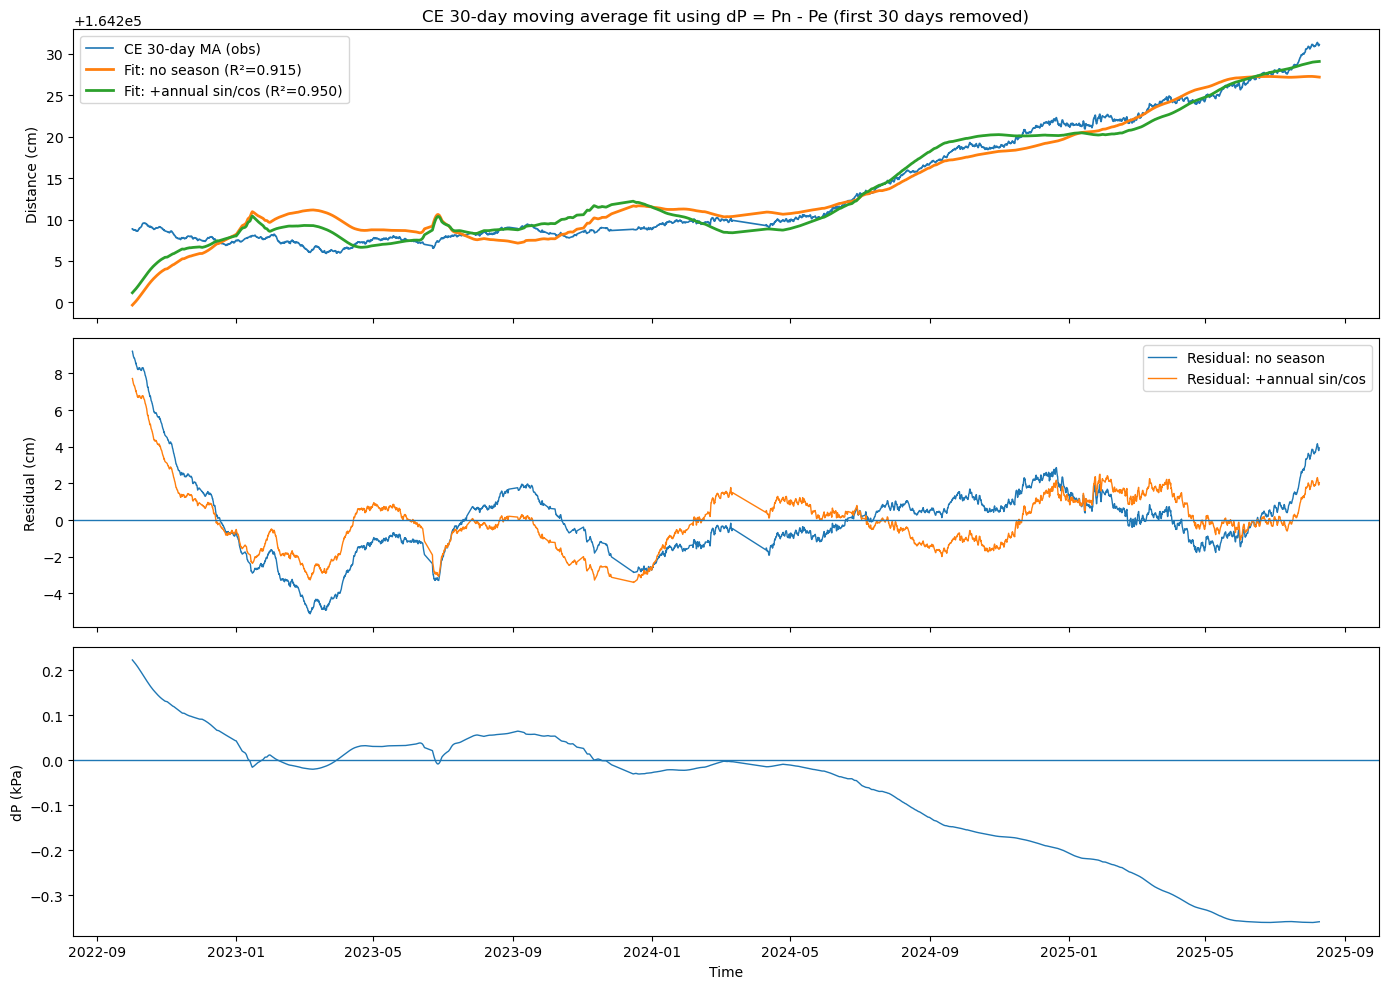

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Files
# -------------------------------
PN_FILE = "Pn_drifcor.csv"
PE_FILE = "Pe_drifcor.csv"
CE_FILE = "CE_distance_corrected.csv"

MERGE_TOL = pd.Timedelta("2h")   # nearest-time matching tolerance
ZSCORE_DP = True                 # z-score dP for stability

# -------------------------------
# Load
# -------------------------------
pn = pd.read_csv(PN_FILE)
pe = pd.read_csv(PE_FILE)
ce = pd.read_csv(CE_FILE)

pn["time"] = pd.to_datetime(pn["time"], utc=True, errors="coerce")
pe["time"] = pd.to_datetime(pe["time"], utc=True, errors="coerce")
ce["Record Time"] = pd.to_datetime(ce["Record Time"], utc=True, errors="coerce")

pn = pn.dropna(subset=["time"]).sort_values("time").rename(columns={"pressure_kPa": "Pn_kPa"})
pe = pe.dropna(subset=["time"]).sort_values("time").rename(columns={"pressure_kPa": "Pe_kPa"})
ce = ce.dropna(subset=["Record Time"]).sort_values("Record Time")

# -------------------------------
# Remove first 30 days of data (based on CE start time)
# -------------------------------
t0 = ce["Record Time"].iloc[0]
t_cut = t0 + pd.Timedelta(days=30)

ce = ce[ce["Record Time"] >= t_cut].copy()
pn = pn[pn["time"] >= t_cut].copy()
pe = pe[pe["time"] >= t_cut].copy()

# -------------------------------
# Align pressures onto CE timestamps
# -------------------------------
df = pd.merge_asof(
    ce[["Record Time", "Moving Average (cm)"]],
    pn[["time", "Pn_kPa"]],
    left_on="Record Time", right_on="time",
    direction="nearest", tolerance=MERGE_TOL
).drop(columns=["time"], errors="ignore")

df = pd.merge_asof(
    df.sort_values("Record Time"),
    pe[["time", "Pe_kPa"]],
    left_on="Record Time", right_on="time",
    direction="nearest", tolerance=MERGE_TOL
).drop(columns=["time"], errors="ignore")

df = df.dropna(subset=["Moving Average (cm)", "Pn_kPa", "Pe_kPa"]).copy()

# -------------------------------
# Build shared terms
# -------------------------------
df["dP_kPa"] = df["Pn_kPa"] - df["Pe_kPa"]

t_days = (df["Record Time"] - df["Record Time"].iloc[0]).dt.total_seconds().to_numpy() / 86400.0

dp = df["dP_kPa"].to_numpy()
dp_term = (dp - dp.mean()) / dp.std() if ZSCORE_DP else dp

y = df["Moving Average (cm)"].to_numpy()

# Seasonal terms
T_year = 365.25
w = 2.0 * np.pi / T_year
sin_t = np.sin(w * t_days)
cos_t = np.cos(w * t_days)

# -------------------------------
# Model 1: WITHOUT seasonal components
#   y = C + a*dP
# -------------------------------
A_ns = np.column_stack([np.ones_like(dp_term), dp_term])
x_ns, *_ = np.linalg.lstsq(A_ns, y, rcond=None)
yfit_ns = A_ns @ x_ns
res_ns = y - yfit_ns

# -------------------------------
# Model 2: WITH seasonal components
#   y = C + a*dP + b*sin + c*cos
# -------------------------------
A_s = np.column_stack([np.ones_like(dp_term), dp_term, sin_t, cos_t])
x_s, *_ = np.linalg.lstsq(A_s, y, rcond=None)
yfit_s = A_s @ x_s
res_s = y - yfit_s

# R^2 helper
def r2(y, yhat):
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1.0 - ss_res / ss_tot

r2_ns = r2(y, yfit_ns)
r2_s  = r2(y, yfit_s)

print("==== Fit target: CE Moving Average (cm) ====")
print("Dropped first 30 days starting from:", t0)
print("dP used:", "z-scored (Pn-Pe)" if ZSCORE_DP else "raw kPa (Pn-Pe)")
print(f"\n-- No-season model: y = C + a*dP  | R^2 = {r2_ns:.4f}")
print(f"   C  : {x_ns[0]: .6f}")
print(f"   a  : {x_ns[1]: .6f}")

print(f"\n-- Seasonal model: y = C + a*dP + b*sin + c*cos  | R^2 = {r2_s:.4f}")
print(f"   C  : {x_s[0]: .6f}")
print(f"   a  : {x_s[1]: .6f}")
print(f"   b  : {x_s[2]: .6f}")
print(f"   c  : {x_s[3]: .6f}")

# -------------------------------
# Plots (modified / comparison layout)
#   1) Observed + both fits
#   2) Residuals (no-season and seasonal)
#   3) dP time series
# -------------------------------
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: data + fits
ax[0].plot(df["Record Time"], y, lw=1.2, label="CE 30-day MA (obs)")
ax[0].plot(df["Record Time"], yfit_ns, lw=2.0, label=f"Fit: no season (R²={r2_ns:.3f})")
ax[0].plot(df["Record Time"], yfit_s,  lw=2.0, label=f"Fit: +annual sin/cos (R²={r2_s:.3f})")
ax[0].set_ylabel("Distance (cm)")
ax[0].set_title("CE 30-day moving average fit using dP = Pn - Pe (first 30 days removed)")
ax[0].legend()

# Panel 2: residuals
ax[1].plot(df["Record Time"], res_ns, lw=1.0, label="Residual: no season")
ax[1].plot(df["Record Time"], res_s,  lw=1.0, label="Residual: +annual sin/cos")
ax[1].axhline(0, lw=1)
ax[1].set_ylabel("Residual (cm)")
ax[1].legend()

# Panel 3: dP
ax[2].plot(df["Record Time"], df["dP_kPa"], lw=1.0)
ax[2].axhline(0, lw=1)
ax[2].set_ylabel("dP (kPa)")
ax[2].set_xlabel("Time")

plt.tight_layout()
plt.show()


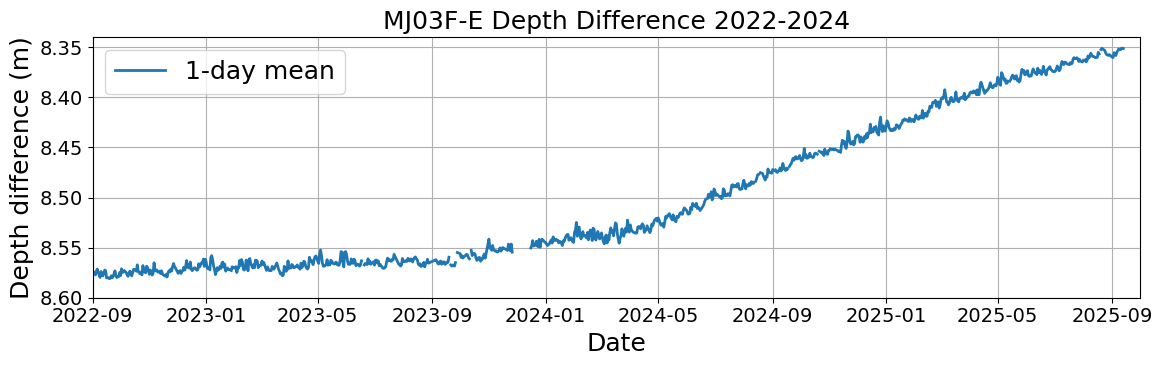

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# ====================================================================
# 1) LOAD RAW CP AND EP DATA
# ====================================================================
# Load CP (central) data
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)
cp = pd.concat(df_list, ignore_index=True).sort_values('time')
cp['time'] = pd.to_datetime(cp['time'])

# Load EP (edge) data
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)
ep = pd.concat(df_list, ignore_index=True).sort_values('time')
ep['time'] = pd.to_datetime(ep['time'])

# ====================================================================
# 2) ALIGN AND COMPUTE DIFFERENCES
# ====================================================================
cp_ = cp.copy()
ep_ = ep.copy()

cp_["time"] = pd.to_datetime(cp_["time"], errors="coerce")
ep_["time"] = pd.to_datetime(ep_["time"], errors="coerce")

# Strip timezone
for df in (cp_, ep_):
    try:
        df["time"] = df["time"].dt.tz_convert(None)
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None)
        except Exception:
            pass

# Ensure numeric
for col in ["rawpsi", "depth"]:
    cp_[col] = pd.to_numeric(cp_[col], errors="coerce")
    ep_[col] = pd.to_numeric(ep_[col], errors="coerce")

cp_ = cp_.dropna(subset=["time", "rawpsi", "depth"])
ep_ = ep_.dropna(subset=["time", "rawpsi", "depth"])

# Merge on time
diff_df = pd.merge(
    cp_[["time", "rawpsi", "depth"]],
    ep_[["time", "rawpsi", "depth"]],
    on="time",
    how="inner",
    suffixes=("_cp", "_ep"),
)

diff_df["depth_cp_minus_ep"] = diff_df["depth_cp"] - diff_df["depth_ep"]

# ====================================================================
# 3) DAILY RESAMPLING
# ====================================================================
daily_df = (
    diff_df.set_index("time")[["depth_cp_minus_ep"]]
           .resample("1D")
           .mean()
           .reset_index()
           .rename(columns={"depth_cp_minus_ep": "depth_m"})
)

df_1day = daily_df

# ====================================================================
# 4) OUTLIER REMOVAL (HAMPEL)
# ====================================================================
def hampel_outliers(s: pd.Series, window: int = 9, n_sigmas: float = 4.5) -> pd.Series:
    """Return boolean mask of outliers using rolling median + MAD."""
    med = s.rolling(window, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=1).median()
    sigma = 1.4826 * mad
    return (s - med).abs() > n_sigmas * sigma

df = df_1day.copy()
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
df = df.dropna(subset=["time", "depth_m"]).sort_values("time").set_index("time")
mask = hampel_outliers(df["depth_m"], window=9, n_sigmas=4.5)
df["depth_m_no_out"] = df["depth_m"].where(~mask)
df_1day = df.reset_index()

# ====================================================================
# 5) PLOT
# ====================================================================
plt.figure(figsize=(12, 4))
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 18,
})
plt.plot(df_1day["time"], df_1day["depth_m_no_out"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2025, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.34)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

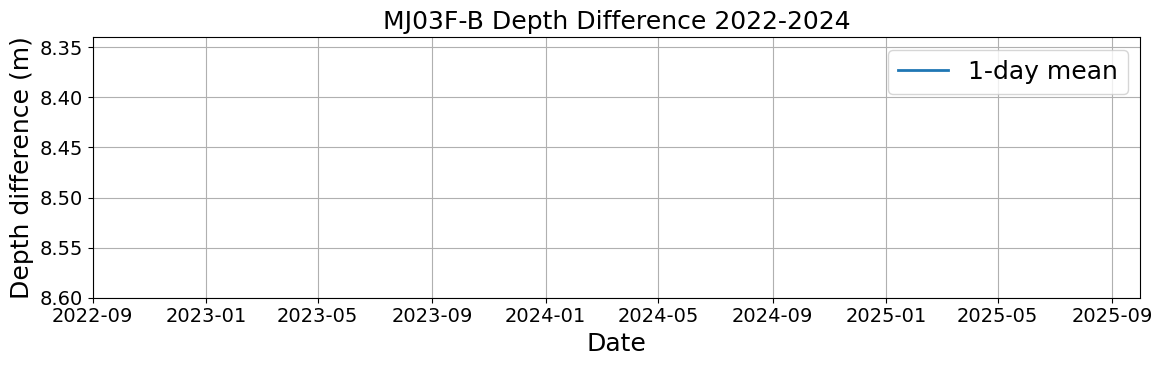

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# ====================================================================
# 1) LOAD RAW CP AND EP DATA
# ====================================================================
# Load CP (central) data
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)
cp = pd.concat(df_list, ignore_index=True).sort_values('time')
cp['time'] = pd.to_datetime(cp['time'])

# Load EP (edge) data
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03B*.Data")
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)
ep = pd.concat(df_list, ignore_index=True).sort_values('time')
ep['time'] = pd.to_datetime(ep['time'])

# ====================================================================
# 2) ALIGN AND COMPUTE DIFFERENCES
# ====================================================================
cp_ = cp.copy()
ep_ = ep.copy()

cp_["time"] = pd.to_datetime(cp_["time"], errors="coerce")
ep_["time"] = pd.to_datetime(ep_["time"], errors="coerce")

# Strip timezone
for df in (cp_, ep_):
    try:
        df["time"] = df["time"].dt.tz_convert(None)
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None)
        except Exception:
            pass

# Ensure numeric
for col in ["rawpsi", "depth"]:
    cp_[col] = pd.to_numeric(cp_[col], errors="coerce")
    ep_[col] = pd.to_numeric(ep_[col], errors="coerce")

cp_ = cp_.dropna(subset=["time", "rawpsi", "depth"])
ep_ = ep_.dropna(subset=["time", "rawpsi", "depth"])

# Merge on time
diff_df = pd.merge(
    cp_[["time", "rawpsi", "depth"]],
    ep_[["time", "rawpsi", "depth"]],
    on="time",
    how="inner",
    suffixes=("_cp", "_ep"),
)

diff_df["depth_cp_minus_ep"] = diff_df["depth_cp"] - diff_df["depth_ep"]

# ====================================================================
# 3) DAILY RESAMPLING
# ====================================================================
daily_df = (
    diff_df.set_index("time")[["depth_cp_minus_ep"]]
           .resample("1D")
           .mean()
           .reset_index()
           .rename(columns={"depth_cp_minus_ep": "depth_m"})
)

df_1day = daily_df

# ====================================================================
# 4) OUTLIER REMOVAL (HAMPEL)
# ====================================================================
def hampel_outliers(s: pd.Series, window: int = 9, n_sigmas: float = 4.5) -> pd.Series:
    """Return boolean mask of outliers using rolling median + MAD."""
    med = s.rolling(window, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=1).median()
    sigma = 1.4826 * mad
    return (s - med).abs() > n_sigmas * sigma

df = df_1day.copy()
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
df = df.dropna(subset=["time", "depth_m"]).sort_values("time").set_index("time")
mask = hampel_outliers(df["depth_m"], window=9, n_sigmas=4.5)
df["depth_m_no_out"] = df["depth_m"].where(~mask)
df_1day = df.reset_index()



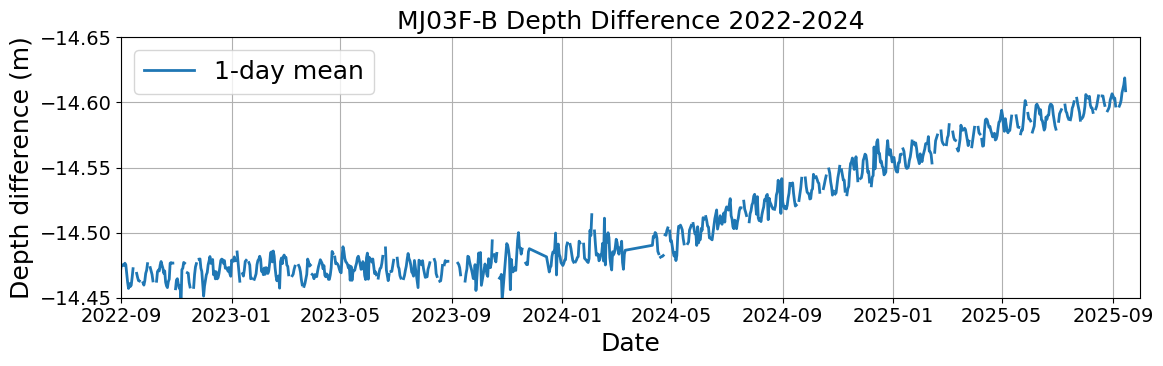

In [76]:
# ====================================================================
# 5) PLOT
# ====================================================================
plt.figure(figsize=(12, 4))
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 18,
})
plt.plot(df_1day["time"], df_1day["depth_m_no_out"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2025, 10, 1, tz="UTC"))
plt.ylim(-14.45, -14.65)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
diff_df

,time,rawpsi_cp,depth_cp,rawpsi_ep,depth_ep,depth_cp_minus_ep
0,2016-01-01 00:00:00,2256.901400,1511.627900,2242.754300,1502.149200,9.478700
1,2016-01-01 00:00:15,2256.896600,1511.624600,2242.759300,1502.152400,9.472200
2,2016-01-01 00:00:30,2256.891800,1511.621200,2242.760000,1502.152700,9.468500
3,2016-01-01 00:00:45,2256.892700,1511.621700,2242.757200,1502.150800,9.470900
4,2016-01-01 00:01:00,2256.893700,1511.622100,2242.751600,1502.146900,9.475200
...,...,...,...,...,...,...
19260490,2025-09-15 00:27:00,2254.769943,1509.714562,2242.319544,1501.369995,8.344567
19260491,2025-09-15 00:27:15,2254.770865,1509.714780,2242.324742,1501.373077,8.341702
19260492,2025-09-15 00:27:30,2254.771606,1509.714876,2242.326490,1501.373848,8.341027
19260493,2025-09-15 00:27:45,2254.774897,1509.716581,2242.323897,1501.371711,8.344870


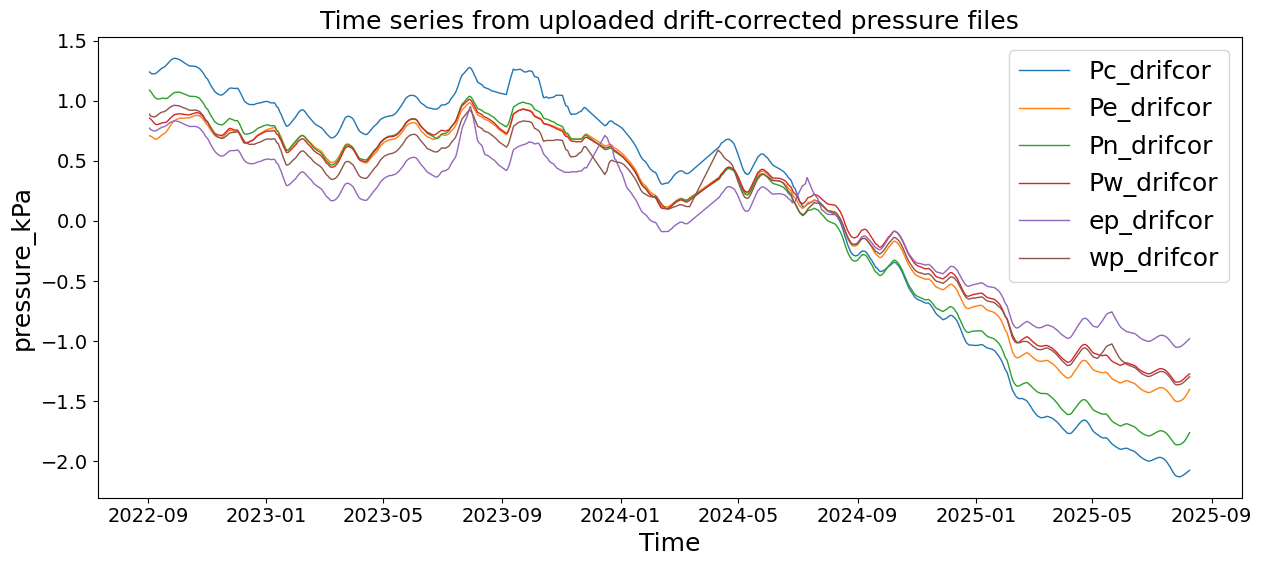

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

files = [
    ("Pc_drifcor.csv", "Pc_drifcor"),
    ("Pe_drifcor.csv", "Pe_drifcor"),
    ("Pn_drifcor.csv", "Pn_drifcor"),
    ("Pw_drifcor.csv", "Pw_drifcor"),
    ("ep_drifcor.csv", "ep_drifcor"),
    ("wp_drifcor.csv", "wp_drifcor"),
]

plt.figure(figsize=(13, 6))

for path, label in files:
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    plt.plot(df["time"], df["pressure_kPa"], lw=1, label=label)

plt.xlabel("Time")
plt.ylabel("pressure_kPa")
plt.title("Time series from uploaded drift-corrected pressure files")
plt.legend()
plt.tight_layout()
plt.show()


==== Fit: CE Moving Average (cm) using Pc only + annual sin/cos ====
Dropped first 30 days starting from: 2022-09-01 19:30:00+00:00
Pc used: z-scored
N: 5361  R^2: 0.9898
     C :  164214.414260
  a_Pc : -7.421797
 b_sin : -0.389094
 c_cos :  1.860991


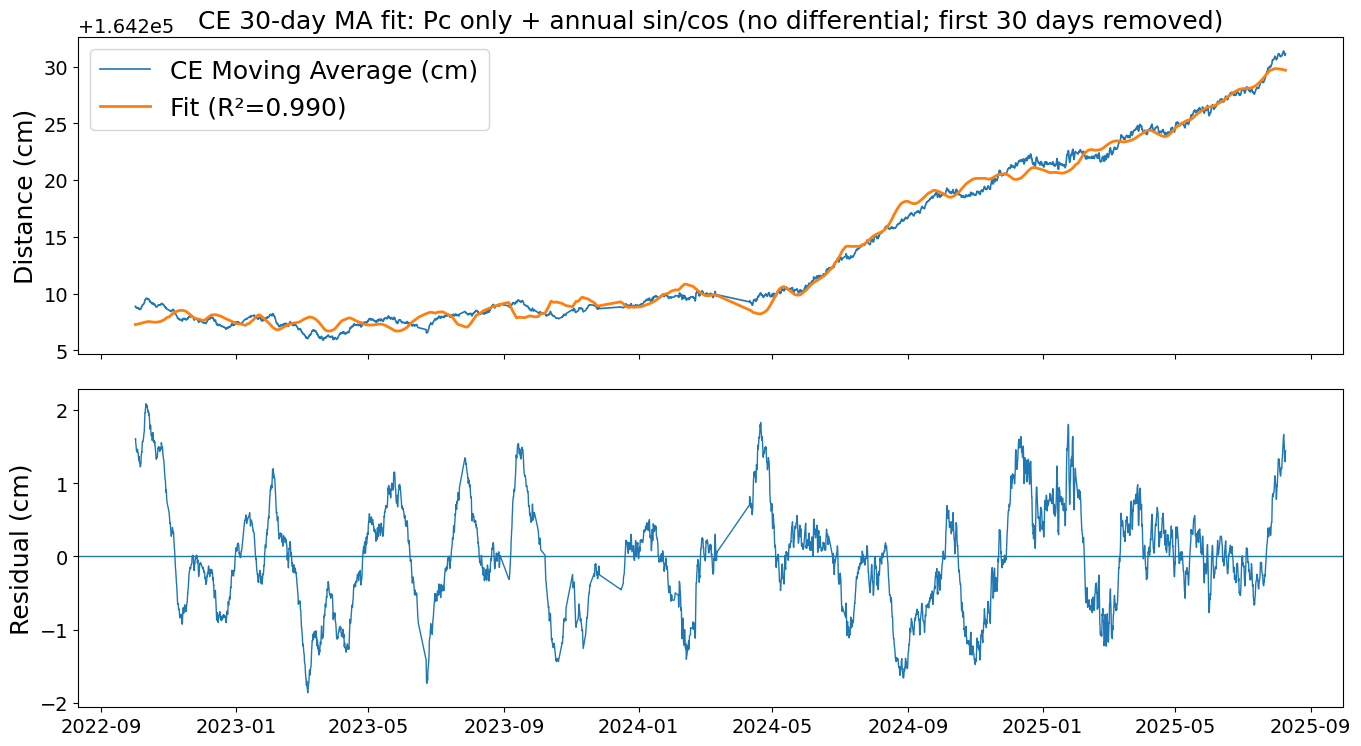

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Files
# -------------------------------
PC_FILE = "Pc_drifcor.csv"
CE_FILE = "CE_distance_corrected.csv"

MERGE_TOL = pd.Timedelta("2h")   # nearest-time matching tolerance
ZSCORE_PC = True                # set False if you want coefficient in cm per kPa

# -------------------------------
# Load
# -------------------------------
pc = pd.read_csv(PC_FILE)
ce = pd.read_csv(CE_FILE)

pc["time"] = pd.to_datetime(pc["time"], utc=True, errors="coerce")
ce["Record Time"] = pd.to_datetime(ce["Record Time"], utc=True, errors="coerce")

pc = pc.dropna(subset=["time"]).sort_values("time").rename(columns={"pressure_kPa": "Pc_kPa"})
ce = ce.dropna(subset=["Record Time"]).sort_values("Record Time")

# -------------------------------
# Remove first 30 days (based on CE start)
# -------------------------------
t0 = ce["Record Time"].iloc[0]
t_cut = t0 + pd.Timedelta(days=30)

ce = ce[ce["Record Time"] >= t_cut].copy()
pc = pc[pc["time"] >= t_cut].copy()

# -------------------------------
# Align Pc onto CE timestamps
# -------------------------------
df = pd.merge_asof(
    ce[["Record Time", "Moving Average (cm)"]],
    pc[["time", "Pc_kPa"]],
    left_on="Record Time", right_on="time",
    direction="nearest", tolerance=MERGE_TOL
).drop(columns=["time"], errors="ignore")

df = df.dropna(subset=["Moving Average (cm)", "Pc_kPa"]).copy()

# -------------------------------
# Model: CE_MA = C + a*Pc + b*sin(ωt) + c*cos(ωt)
# -------------------------------
t_days = (df["Record Time"] - df["Record Time"].iloc[0]).dt.total_seconds().to_numpy() / 86400.0
T_year = 365.25
w = 2.0 * np.pi / T_year
sin_t = np.sin(w * t_days)
cos_t = np.cos(w * t_days)

pc_vals = df["Pc_kPa"].to_numpy()
pc_term = (pc_vals - pc_vals.mean()) / pc_vals.std() if ZSCORE_PC else pc_vals

A = np.column_stack([np.ones_like(pc_term), pc_term, sin_t, cos_t])
names = ["C", "a_Pc", "b_sin", "c_cos"]

y = df["Moving Average (cm)"].to_numpy()

# Fit
x, *_ = np.linalg.lstsq(A, y, rcond=None)
y_fit = A @ x
resid = y - y_fit

ss_res = np.sum(resid**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1.0 - ss_res / ss_tot

print("==== Fit: CE Moving Average (cm) using Pc only + annual sin/cos ====")
print("Dropped first 30 days starting from:", t0)
print("Pc used:", "z-scored" if ZSCORE_PC else "raw kPa")
print("N:", len(df), " R^2:", f"{r2:.4f}")
for n, v in zip(names, x):
    print(f"{n:>6s} : {v: .6f}")

# -------------------------------
# Plots (modified: include Pc)
# -------------------------------
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(df["Record Time"], y, lw=1.2, label="CE Moving Average (cm)")
ax[0].plot(df["Record Time"], y_fit, lw=2.0, label=f"Fit (R²={r2:.3f})")
ax[0].set_ylabel("Distance (cm)")
ax[0].set_title("CE 30-day MA fit: Pc only + annual sin/cos (no differential; first 30 days removed)")
ax[0].legend()

ax[1].plot(df["Record Time"], resid, lw=1.0)
ax[1].axhline(0, lw=1)
ax[1].set_ylabel("Residual (cm)")

plt.tight_layout()
plt.show()


==== Fit: WC Moving Average (cm) using Pc only + annual sin/cos ====
Dropped first 30 days starting from: 2022-09-01 12:30:00+00:00
Pc used: z-scored
N: 5399  R^2: 0.5706
     C :  176562.114878
  a_Pc : -0.829104
 b_sin : -0.146779
 c_cos :  1.275314


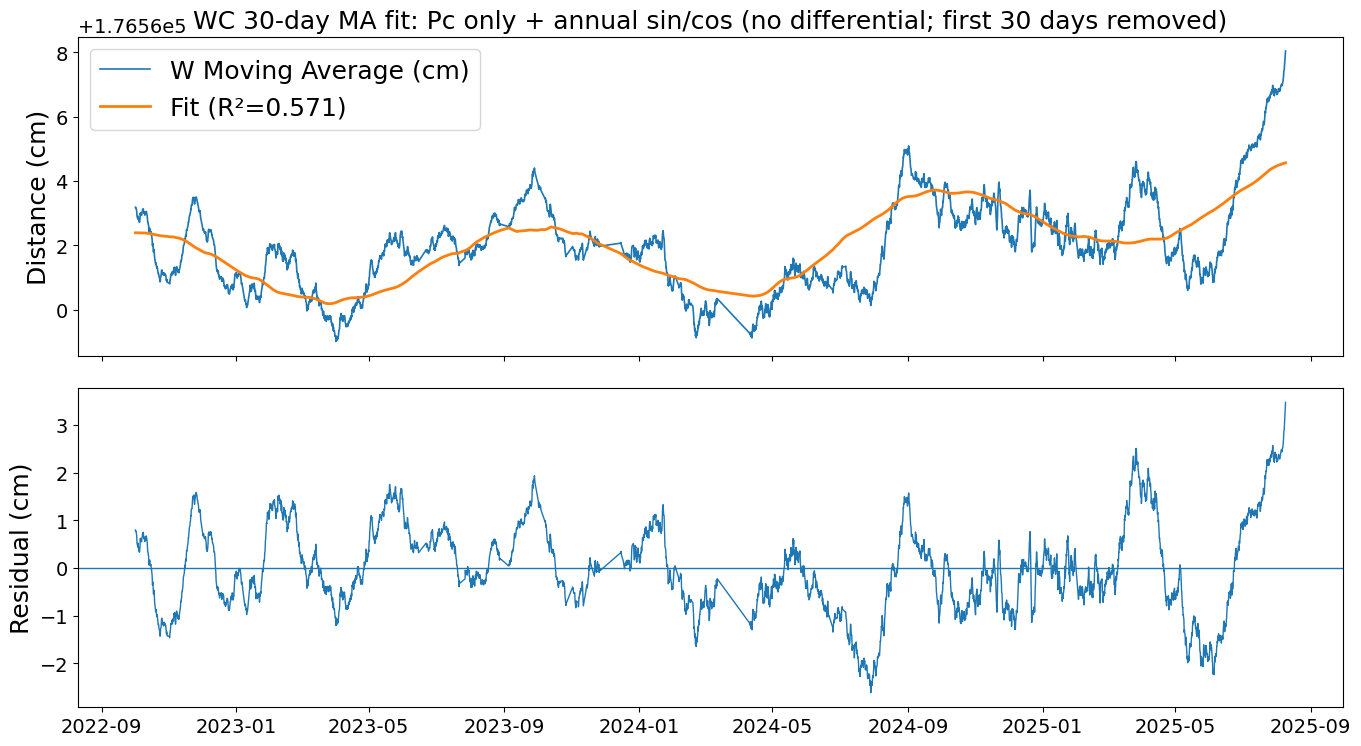

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Files
# -------------------------------
PC_FILE = "Pc_drifcor.csv"
CE_FILE = "WC_distance_corrected.csv"

MERGE_TOL = pd.Timedelta("2h")   # nearest-time matching tolerance
ZSCORE_PC = True                # set False if you want coefficient in cm per kPa

# -------------------------------
# Load
# -------------------------------
pc = pd.read_csv(PC_FILE)
ce = pd.read_csv(CE_FILE)

pc["time"] = pd.to_datetime(pc["time"], utc=True, errors="coerce")
ce["Record Time"] = pd.to_datetime(ce["Record Time"], utc=True, errors="coerce")

pc = pc.dropna(subset=["time"]).sort_values("time").rename(columns={"pressure_kPa": "Pc_kPa"})
ce = ce.dropna(subset=["Record Time"]).sort_values("Record Time")

# -------------------------------
# Remove first 30 days (based on CE start)
# -------------------------------
t0 = ce["Record Time"].iloc[0]
t_cut = t0 + pd.Timedelta(days=30)

ce = ce[ce["Record Time"] >= t_cut].copy()
pc = pc[pc["time"] >= t_cut].copy()

# -------------------------------
# Align Pc onto CE timestamps
# -------------------------------
df = pd.merge_asof(
    ce[["Record Time", "Moving Average (cm)"]],
    pc[["time", "Pc_kPa"]],
    left_on="Record Time", right_on="time",
    direction="nearest", tolerance=MERGE_TOL
).drop(columns=["time"], errors="ignore")

df = df.dropna(subset=["Moving Average (cm)", "Pc_kPa"]).copy()

# -------------------------------
# Model: CE_MA = C + a*Pc + b*sin(ωt) + c*cos(ωt)
# -------------------------------
t_days = (df["Record Time"] - df["Record Time"].iloc[0]).dt.total_seconds().to_numpy() / 86400.0
T_year = 365.25
w = 2.0 * np.pi / T_year
sin_t = np.sin(w * t_days)
cos_t = np.cos(w * t_days)

pc_vals = df["Pc_kPa"].to_numpy()
pc_term = (pc_vals - pc_vals.mean()) / pc_vals.std() if ZSCORE_PC else pc_vals

A = np.column_stack([np.ones_like(pc_term), pc_term, sin_t, cos_t])
names = ["C", "a_Pc", "b_sin", "c_cos"]

y = df["Moving Average (cm)"].to_numpy()

# Fit
x, *_ = np.linalg.lstsq(A, y, rcond=None)
y_fit = A @ x
resid = y - y_fit

ss_res = np.sum(resid**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1.0 - ss_res / ss_tot

print("==== Fit: WC Moving Average (cm) using Pc only + annual sin/cos ====")
print("Dropped first 30 days starting from:", t0)
print("Pc used:", "z-scored" if ZSCORE_PC else "raw kPa")
print("N:", len(df), " R^2:", f"{r2:.4f}")
for n, v in zip(names, x):
    print(f"{n:>6s} : {v: .6f}")

# -------------------------------
# Plots (modified: include Pc)
# -------------------------------
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(df["Record Time"], y, lw=1.2, label="W Moving Average (cm)")
ax[0].plot(df["Record Time"], y_fit, lw=2.0, label=f"Fit (R²={r2:.3f})")
ax[0].set_ylabel("Distance (cm)")
ax[0].set_title("WC 30-day MA fit: Pc only + annual sin/cos (no differential; first 30 days removed)")
ax[0].legend()

ax[1].plot(df["Record Time"], resid, lw=1.0)
ax[1].axhline(0, lw=1)
ax[1].set_ylabel("Residual (cm)")

plt.tight_layout()
plt.show()


==== Fit: WE Moving Average (cm) using Pc only + annual sin/cos ====
Dropped first 30 days starting from: 2022-08-31 16:30:00+00:00
Pc used: z-scored
N: 5399  R^2: 0.9562
     C :  326024.342663
  a_Pc : -7.884345
 b_sin : -1.811565
 c_cos :  3.584532


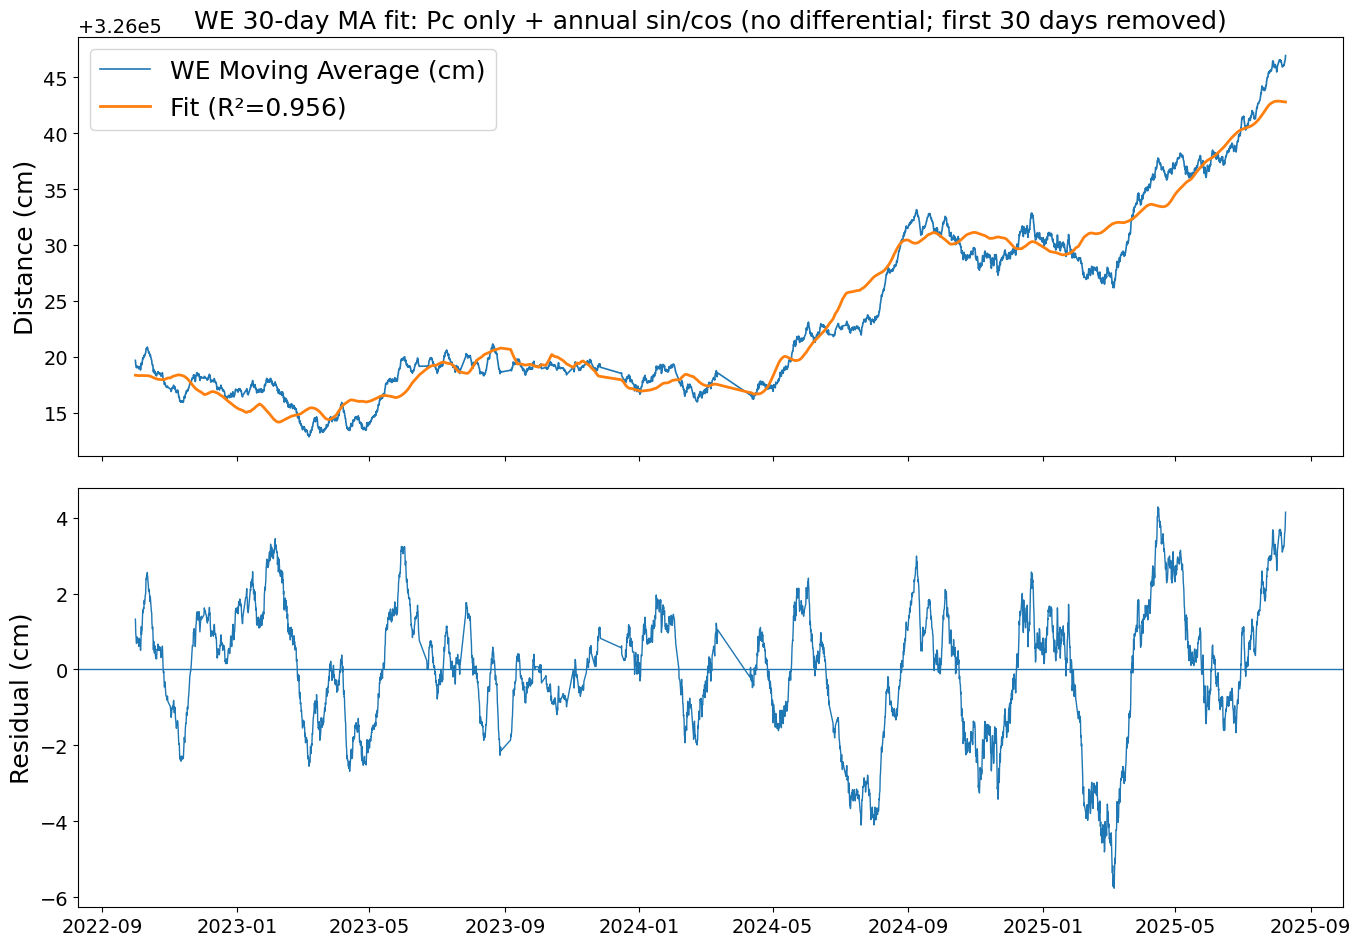

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Files
# -------------------------------
PC_FILE = "Pc_drifcor.csv"
CE_FILE = "WE_distance_corrected.csv"

MERGE_TOL = pd.Timedelta("2h")   # nearest-time matching tolerance
ZSCORE_PC = True                # set False if you want coefficient in cm per kPa

# -------------------------------
# Load
# -------------------------------
pc = pd.read_csv(PC_FILE)
ce = pd.read_csv(CE_FILE)

pc["time"] = pd.to_datetime(pc["time"], utc=True, errors="coerce")
ce["Record Time"] = pd.to_datetime(ce["Record Time"], utc=True, errors="coerce")

pc = pc.dropna(subset=["time"]).sort_values("time").rename(columns={"pressure_kPa": "Pc_kPa"})
ce = ce.dropna(subset=["Record Time"]).sort_values("Record Time")

# -------------------------------
# Remove first 30 days (based on CE start)
# -------------------------------
t0 = ce["Record Time"].iloc[0]
t_cut = t0 + pd.Timedelta(days=30)

ce = ce[ce["Record Time"] >= t_cut].copy()
pc = pc[pc["time"] >= t_cut].copy()

# -------------------------------
# Align Pc onto CE timestamps
# -------------------------------
df = pd.merge_asof(
    ce[["Record Time", "Moving Average (cm)"]],
    pc[["time", "Pc_kPa"]],
    left_on="Record Time", right_on="time",
    direction="nearest", tolerance=MERGE_TOL
).drop(columns=["time"], errors="ignore")

df = df.dropna(subset=["Moving Average (cm)", "Pc_kPa"]).copy()

# -------------------------------
# Model: CE_MA = C + a*Pc + b*sin(ωt) + c*cos(ωt)
# -------------------------------
t_days = (df["Record Time"] - df["Record Time"].iloc[0]).dt.total_seconds().to_numpy() / 86400.0
T_year = 365.25
w = 2.0 * np.pi / T_year
sin_t = np.sin(w * t_days)
cos_t = np.cos(w * t_days)

pc_vals = df["Pc_kPa"].to_numpy()
pc_term = (pc_vals - pc_vals.mean()) / pc_vals.std() if ZSCORE_PC else pc_vals

A = np.column_stack([np.ones_like(pc_term), pc_term, sin_t, cos_t])
names = ["C", "a_Pc", "b_sin", "c_cos"]

y = df["Moving Average (cm)"].to_numpy()

# Fit
x, *_ = np.linalg.lstsq(A, y, rcond=None)
y_fit = A @ x
resid = y - y_fit

ss_res = np.sum(resid**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1.0 - ss_res / ss_tot

print("==== Fit: WE Moving Average (cm) using Pc only + annual sin/cos ====")
print("Dropped first 30 days starting from:", t0)
print("Pc used:", "z-scored" if ZSCORE_PC else "raw kPa")
print("N:", len(df), " R^2:", f"{r2:.4f}")
for n, v in zip(names, x):
    print(f"{n:>6s} : {v: .6f}")

# -------------------------------
# Plots (modified: include Pc)
# -------------------------------
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax[0].plot(df["Record Time"], y, lw=1.2, label="WE Moving Average (cm)")
ax[0].plot(df["Record Time"], y_fit, lw=2.0, label=f"Fit (R²={r2:.3f})")
ax[0].set_ylabel("Distance (cm)")
ax[0].set_title("WE 30-day MA fit: Pc only + annual sin/cos (no differential; first 30 days removed)")
ax[0].legend()

ax[1].plot(df["Record Time"], resid, lw=1.0)
ax[1].axhline(0, lw=1)
ax[1].set_ylabel("Residual (cm)")

plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import pandas as pd

def seasonal_amp_phase_and_minmax_dates(b, c, t0, T_year=365.25):
    w = 2*np.pi / T_year
    A = np.sqrt(b*b + c*c)
    phi = np.arctan2(b, c)  # radians

    # y_season = A*cos(w t - phi)
    # max when (w t - phi)=0  -> t_max = phi/w
    # min when (w t - phi)=pi -> t_min = (phi+pi)/w
    t_max = (phi / w) % T_year
    t_min = ((phi + np.pi) / w) % T_year

    t0 = pd.Timestamp(t0)
    return A, phi, t0 + pd.Timedelta(days=float(t_min)), t0 + pd.Timedelta(days=float(t_max))

# Example usage:
# CE:
A, phi, tmin, tmax = seasonal_amp_phase_and_minmax_dates(
    b=-0.389094, c=1.860991,
    t0="2022-10-01 19:30:00+00:00"  # your post-cut start (or df['Record Time'].iloc[0])
)
print("Amp (cm):", A, "Min near:", tmin, "Max near:", tmax)


Amp (cm): 1.9012316121180501 Min near: 2023-03-21 10:56:43.323638174+00:00 Max near: 2023-09-20 01:56:43.323638180+00:00


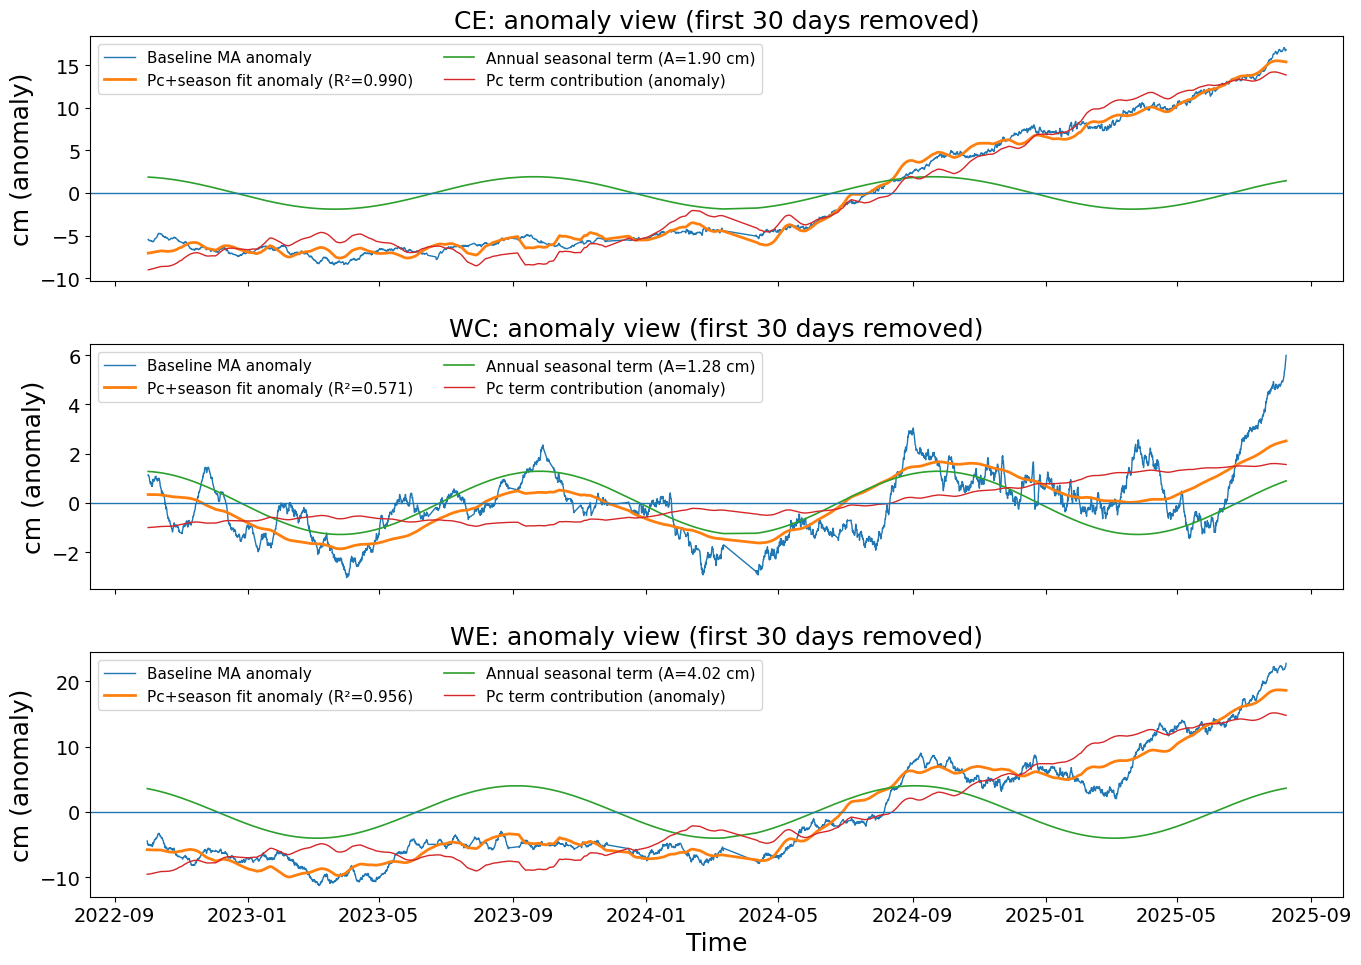

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PC_FILE = "Pc_drifcor.csv"
DIST_FILES = [
    ("CE_distance_corrected.csv", "CE"),
    ("WC_distance_corrected.csv", "WC"),
    ("WE_distance_corrected.csv", "WE"),
]

MERGE_TOL = pd.Timedelta("2h")
ZSCORE_PC = True

def load_pc():
    pc = pd.read_csv(PC_FILE)
    pc["time"] = pd.to_datetime(pc["time"], utc=True, errors="coerce")
    pc = pc.dropna(subset=["time"]).sort_values("time").rename(columns={"pressure_kPa":"Pc_kPa"})
    return pc

def fit_and_components(distance_file, label):
    pc = load_pc()
    d = pd.read_csv(distance_file)
    d["Record Time"] = pd.to_datetime(d["Record Time"], utc=True, errors="coerce")
    d = d.dropna(subset=["Record Time"]).sort_values("Record Time")
    ycol = "Moving Average (cm)"

    # drop first 30 days based on baseline start time
    t0 = d["Record Time"].iloc[0]
    t_cut = t0 + pd.Timedelta(days=30)
    d = d[d["Record Time"] >= t_cut].copy()
    pc = pc[pc["time"] >= t_cut].copy()

    # align Pc onto distance timestamps
    df = pd.merge_asof(
        d[["Record Time", ycol]],
        pc[["time", "Pc_kPa"]],
        left_on="Record Time", right_on="time",
        direction="nearest", tolerance=MERGE_TOL
    ).drop(columns=["time"], errors="ignore")

    df = df.dropna(subset=[ycol, "Pc_kPa"]).copy()

    # time + seasonal terms
    t_days = (df["Record Time"] - df["Record Time"].iloc[0]).dt.total_seconds().to_numpy()/86400.0
    T_year = 365.25
    w = 2*np.pi/T_year
    sin_t = np.sin(w*t_days)
    cos_t = np.cos(w*t_days)

    # Pc term
    pc_vals = df["Pc_kPa"].to_numpy()
    pc_term = (pc_vals - pc_vals.mean())/pc_vals.std() if ZSCORE_PC else pc_vals

    # fit y = C + a*Pc + b*sin + c*cos
    A = np.column_stack([np.ones_like(pc_term), pc_term, sin_t, cos_t])
    y = df[ycol].to_numpy()
    x, *_ = np.linalg.lstsq(A, y, rcond=None)

    C, a_pc, b_sin, c_cos = x
    yfit = A @ x
    season_only = b_sin*sin_t + c_cos*cos_t
    pc_only = a_pc*pc_term  # contribution in cm (since y in cm)

    # R^2
    r2 = 1 - np.sum((y-yfit)**2)/np.sum((y-y.mean())**2)

    # seasonal amplitude
    amp = float(np.sqrt(b_sin*b_sin + c_cos*c_cos))
    return {
        "label": label,
        "time": df["Record Time"],
        "y": y,
        "yfit": yfit,
        "season_only": season_only,
        "pc_only": pc_only,
        "r2": float(r2),
        "amp": amp,
        "b": float(b_sin),
        "c": float(c_cos),
    }

fits = [fit_and_components(f, lab) for f, lab in DIST_FILES]

# ---- Plot 1: anomalies with fit and seasonal term (per baseline) ----
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, d in zip(axes, fits):
    y_anom = d["y"] - np.mean(d["y"])
    yfit_anom = d["yfit"] - np.mean(d["yfit"])
    season = d["season_only"]  # already ~zero-mean
    pc_contrib = d["pc_only"] - np.mean(d["pc_only"])

    ax.plot(d["time"], y_anom, lw=1.0, label="Baseline MA anomaly")
    ax.plot(d["time"], yfit_anom, lw=2.0, label=f"Pc+season fit anomaly (R²={d['r2']:.3f})")
    ax.plot(d["time"], season, lw=1.2, label=f"Annual seasonal term (A={d['amp']:.2f} cm)")
    ax.plot(d["time"], pc_contrib, lw=1.0, label="Pc term contribution (anomaly)")

    ax.axhline(0, lw=1)
    ax.set_ylabel("cm (anomaly)")
    ax.set_title(f"{d['label']}: anomaly view (first 30 days removed)")
    ax.legend(ncol=2, fontsize=11)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd

PC_FILE = "Pc_drifcor.csv"
DIST_FILES = [
    ("CE_distance_corrected.csv", "CE"),
    ("WC_distance_corrected.csv", "WC"),
    ("WE_distance_corrected.csv", "WE"),
]

MERGE_TOL = pd.Timedelta("2h")
DROP_DAYS = 30
ZSCORE_PC = False   # False -> b is in cm per kPa; True -> cm per 1σ(Pc)

T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR

def load_pc():
    pc = pd.read_csv(PC_FILE)
    pc["time"] = pd.to_datetime(pc["time"], utc=True, errors="coerce")
    pc = pc.dropna(subset=["time"]).sort_values("time")
    pc = pc.rename(columns={"pressure_kPa": "Pc_kPa"})
    return pc[["time", "Pc_kPa"]]

def fit_one(distance_file):
    pc = load_pc()

    d = pd.read_csv(distance_file)
    d["Record Time"] = pd.to_datetime(d["Record Time"], utc=True, errors="coerce")
    d = d.dropna(subset=["Record Time"]).sort_values("Record Time")

    # remove first 30 days based on baseline start
    t0 = d["Record Time"].iloc[0]
    t_cut = t0 + pd.Timedelta(days=DROP_DAYS)
    d = d[d["Record Time"] >= t_cut].copy()
    pc = pc[pc["time"] >= t_cut].copy()

    # align Pc onto baseline timestamps
    df = pd.merge_asof(
        d[["Record Time", "Moving Average (cm)"]],
        pc,
        left_on="Record Time", right_on="time",
        direction="nearest", tolerance=MERGE_TOL
    ).drop(columns=["time"], errors="ignore")

    df = df.dropna(subset=["Moving Average (cm)", "Pc_kPa"]).copy()

    # time in days since first used sample
    t_days = (df["Record Time"] - df["Record Time"].iloc[0]).dt.total_seconds().to_numpy() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    Pc = df["Pc_kPa"].to_numpy()
    Pc_term = (Pc - Pc.mean()) / Pc.std() if ZSCORE_PC else Pc

    # Fit: y = a + b*Pc + c*sin + d*cos
    A = np.column_stack([np.ones_like(Pc_term), Pc_term, sin_t, cos_t])
    y = df["Moving Average (cm)"].to_numpy()

    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    yfit = A @ x
    r2 = 1.0 - np.sum((y - yfit)**2) / np.sum((y - y.mean())**2)

    a, b, c, dcoef = x
    return a, b, c, dcoef, len(df), r2

print("Fit form: y = a + b*Pc + c*sin(2πt/365.25) + d*cos(2πt/365.25)")
print("Pc term units:", "b is cm per 1σ(Pc)" if ZSCORE_PC else "b is cm per kPa")
print()

for path, name in DIST_FILES:
    a, b, c, dcoef, n, r2 = fit_one(path)
    print(f"==== {name} ====")
    print(f"N   : {n}")
    print(f"R^2 : {r2:.4f}")
    print(f"a (intercept) : {a:.6f}")
    print(f"b (Pc coeff)  : {b:.6f}")
    print(f"c (annual sin): {c:.6f}")
    print(f"d (annual cos): {dcoef:.6f}")
    print()


Fit form: y = a + b*Pc + c*sin(2πt/365.25) + d*cos(2πt/365.25)
Pc term units: b is cm per kPa

==== CE ====
N   : 5361
R^2 : 0.9898
a (intercept) : 164214.399740
b (Pc coeff)  : -6.673264
c (annual sin): -0.389094
d (annual cos): 1.860991

==== WC ====
N   : 5399
R^2 : 0.5706
a (intercept) : 176562.119268
b (Pc coeff)  : -0.747863
c (annual sin): -0.146779
d (annual cos): 1.275314

==== WE ====
N   : 5399
R^2 : 0.9562
a (intercept) : 326024.392661
b (Pc coeff)  : -7.112451
c (annual sin): -1.811565
d (annual cos): 3.584532



==== CE nuisance fit: y = a + b*Pc_z + c*sin + d*cos ====
a (intercept) : 164214.178488
b (Pc_z coeff): -7.335868
c (sin)       : -0.393592
d (cos)       : 1.853800

==== WC nuisance fit: y = a + b*Pc_z + c*sin + d*cos ====
a (intercept) : 176562.090051
b (Pc_z coeff): -0.826379
c (sin)       : -0.148387
d (cos)       : 1.292357

==== WE nuisance fit: y = a + b*Pc_z + c*sin + d*cos ====
a (intercept) : 326024.157858
b (Pc_z coeff): -7.806333
c (sin)       : -1.846276
d (cos)       : 3.575744

PC1 variance explained: 75.9%

Common deformation relative scalings (WE fixed to 1):
  CE loading: 0.212
  WC loading: 0.343
  WE loading: 1.000 (fixed)


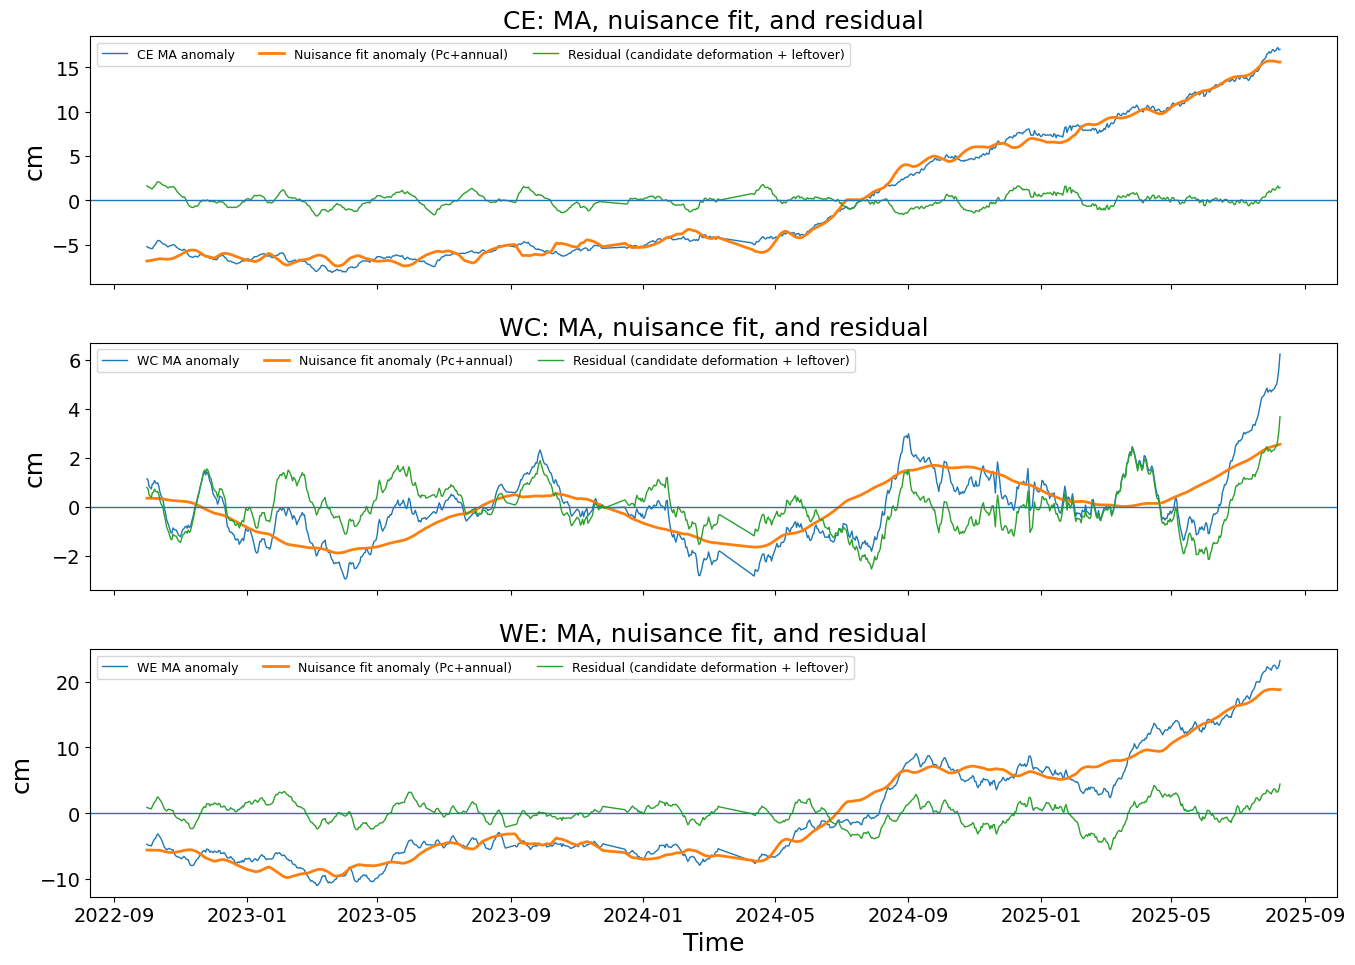

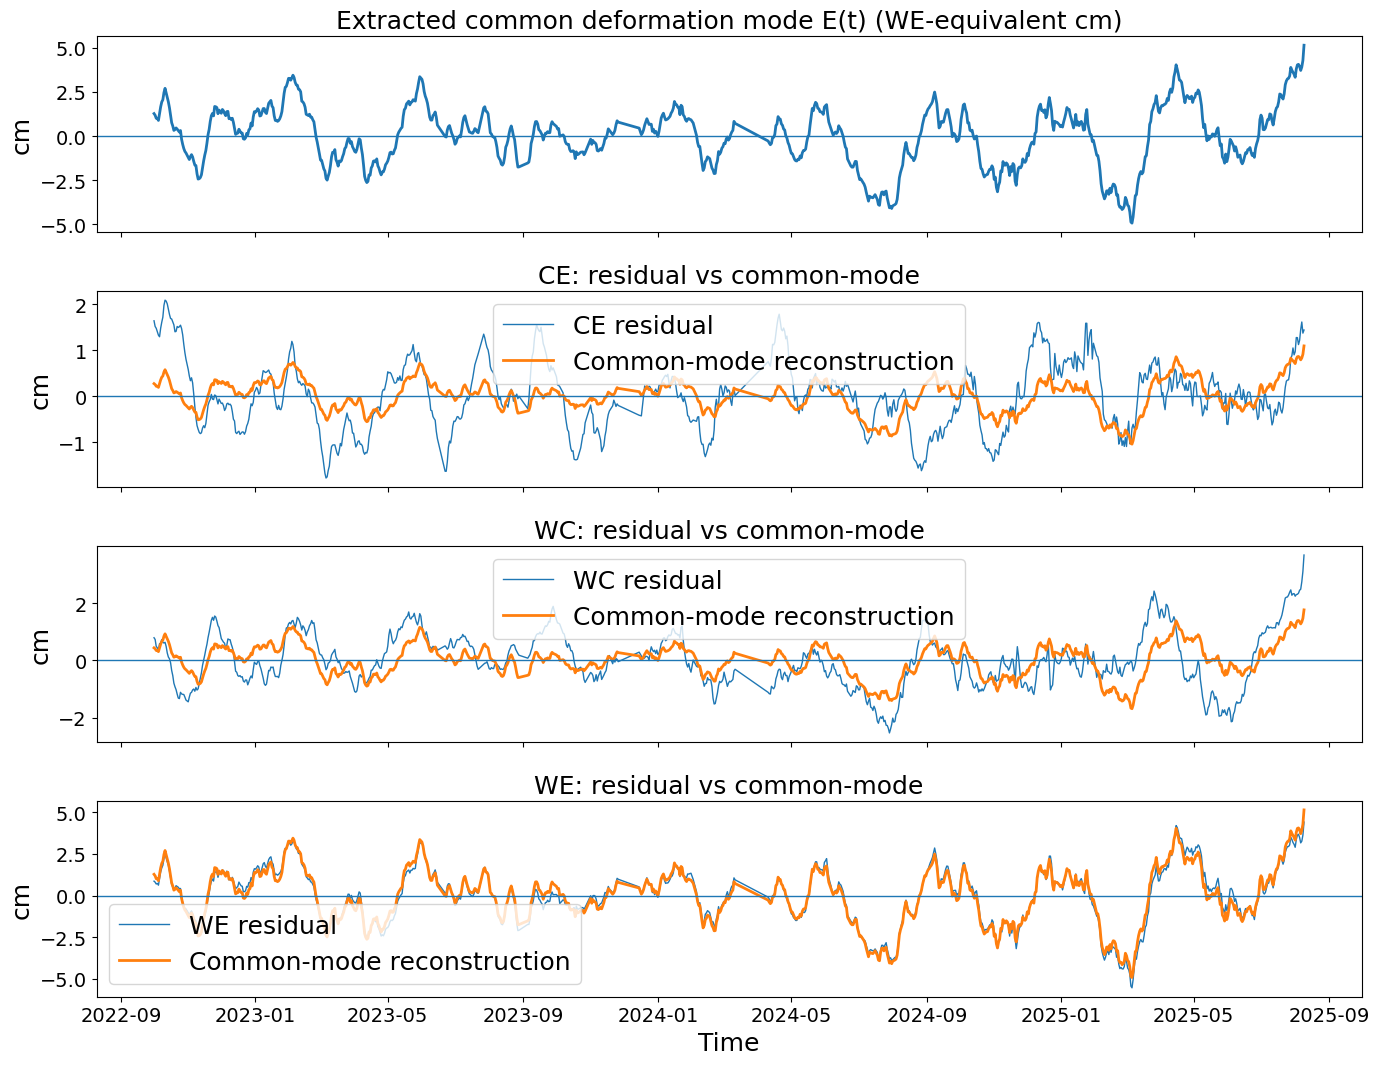

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Files
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

DROP_DAYS = 30

# -----------------------------
# Helpers
# -----------------------------
def load_baseline(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    # daily mean of the 30-day MA (cm)
    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")

    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

def fit_nuisance(y, pc, t0):
    """
    Fit y = a + b*Pc_z + c*sin(wt) + d*cos(wt)
    Returns yfit, resid, coeffs (a,b,c,d)
    """
    # z-score Pc on the aligned window
    Pc = pc.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    t_days = (y.index - t0).total_seconds() / 86400.0
    T_year = 365.25
    w = 2*np.pi / T_year
    sin_t = np.sin(w * t_days)
    cos_t = np.cos(w * t_days)

    A = np.column_stack([np.ones_like(Pc_z), Pc_z, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y.to_numpy(), rcond=None)
    yfit = A @ x
    resid = y.to_numpy() - yfit
    return yfit, resid, x  # a,b,c,d

# -----------------------------
# 1) Load daily series
# -----------------------------
ce = load_baseline(CE_FILE, "CE")
wc = load_baseline(WC_FILE, "WC")
we = load_baseline(WE_FILE, "WE")
pc = load_pc(PC_FILE)

# -----------------------------
# 2) Align to a common daily window
# -----------------------------
df = pd.concat([ce, wc, we, pc], axis=1).dropna()

# Use a fixed time origin for consistent season phase across baselines
t0_common = df.index[0]

# -----------------------------
# 3) Nuisance fits per baseline
# -----------------------------
fits = {}
resids = {}

for name in ["CE", "WC", "WE"]:
    y = df[name]
    yfit, resid, coeffs = fit_nuisance(y, df["Pc_kPa"], t0_common)
    fits[name] = yfit
    resids[name] = resid

    a,b,c,d = coeffs
    print(f"==== {name} nuisance fit: y = a + b*Pc_z + c*sin + d*cos ====")
    print(f"a (intercept) : {a:.6f}")
    print(f"b (Pc_z coeff): {b:.6f}")
    print(f"c (sin)       : {c:.6f}")
    print(f"d (cos)       : {d:.6f}")
    print()

# Build residual matrix R (T x 3)
R = np.column_stack([resids["CE"], resids["WC"], resids["WE"]])

# Center columns (PCA expects zero-mean features)
R_center = R - R.mean(axis=0, keepdims=True)

# -----------------------------
# 4) Joint common deformation mode via SVD (PC1)
# -----------------------------
U, S, Vt = np.linalg.svd(R_center, full_matrices=False)

pc1 = U[:, 0] * S[0]     # time series (arbitrary scaling)
loadings = Vt[0, :]      # [CE, WC, WE] (unit vector)

# Variance explained by PC1
var_expl = (S[0]**2) / np.sum(S**2)
print(f"PC1 variance explained: {var_expl*100:.1f}%")

# Rescale so WE loading = 1 (so the common mode is in "WE-cm" units)
we_loading = loadings[2]
E = pc1 * we_loading                 # common mode in cm (WE-equivalent)
L = loadings / we_loading            # CE/WC/WE relative scalings (WE=1)

print("\nCommon deformation relative scalings (WE fixed to 1):")
print(f"  CE loading: {L[0]:.3f}")
print(f"  WC loading: {L[1]:.3f}")
print(f"  WE loading: {L[2]:.3f} (fixed)")

# Reconstruct residuals using the common mode only
R_common = np.column_stack([L[0]*E, L[1]*E, L[2]*E])

# -----------------------------
# 5) Plots
# -----------------------------
t = df.index

# Plot A: For each baseline, show anomaly, nuisance fit anomaly, residual
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, name in zip(axes, ["CE", "WC", "WE"]):
    y = df[name].to_numpy()
    y_anom = y - np.mean(y)
    yfit_anom = fits[name] - np.mean(fits[name])
    resid = resids[name]

    ax.plot(t, y_anom, lw=1.0, label=f"{name} MA anomaly")
    ax.plot(t, yfit_anom, lw=2.0, label="Nuisance fit anomaly (Pc+annual)")
    ax.plot(t, resid, lw=1.0, label="Residual (candidate deformation + leftover)")
    ax.axhline(0, lw=1)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: MA, nuisance fit, and residual")
    ax.legend(ncol=3, fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Plot B: Common deformation mode and how it reconstructs residuals
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(t, E, lw=2.0)
axes[0].axhline(0, lw=1)
axes[0].set_ylabel("cm")
axes[0].set_title("Extracted common deformation mode E(t) (WE-equivalent cm)")

for i, name in enumerate(["CE", "WC", "WE"], start=1):
    resid = resids[name]
    recon = R_common[:, i-1]
    axes[i].plot(t, resid, lw=1.0, label=f"{name} residual")
    axes[i].plot(t, recon, lw=2.0, label="Common-mode reconstruction")
    axes[i].axhline(0, lw=1)
    axes[i].set_ylabel("cm")
    axes[i].set_title(f"{name}: residual vs common-mode")
    axes[i].legend()

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


In [71]:
wc

Record Time
2022-10-01 00:00:00+00:00    176563.181547
2022-10-02 00:00:00+00:00    176563.121320
2022-10-03 00:00:00+00:00    176562.878855
2022-10-04 00:00:00+00:00    176562.827184
2022-10-05 00:00:00+00:00    176562.768219
                                 ...      
2025-08-20 00:00:00+00:00    176570.361419
2025-08-21 00:00:00+00:00    176570.583877
2025-08-22 00:00:00+00:00    176570.893377
2025-08-23 00:00:00+00:00    176571.141600
2025-08-24 00:00:00+00:00    176571.356546
Freq: D, Name: WC, Length: 1059, dtype: float64

In [73]:
176568.264865-176563.181547

5.083318000019062

==== CE nuisance coefficients (a,b,c,d) ====
a (intercept): 164214.178488
b (Pc_z)     : -7.335868
c (sin)      : -0.393592
d (cos)      : 1.853800

==== WC nuisance coefficients (a,b,c,d) ====
a (intercept): 176562.090051
b (Pc_z)     : -0.826379
c (sin)      : -0.148387
d (cos)      : 1.292357

==== WE nuisance coefficients (a,b,c,d) ====
a (intercept): 326024.157858
b (Pc_z)     : -7.806333
c (sin)      : -1.846276
d (cos)      : 3.575744

Common mode (PC1) variance explained in residuals: 75.9%
Loadings [CE, WC, WE]: [-0.19679908 -0.31775724 -0.92752383]


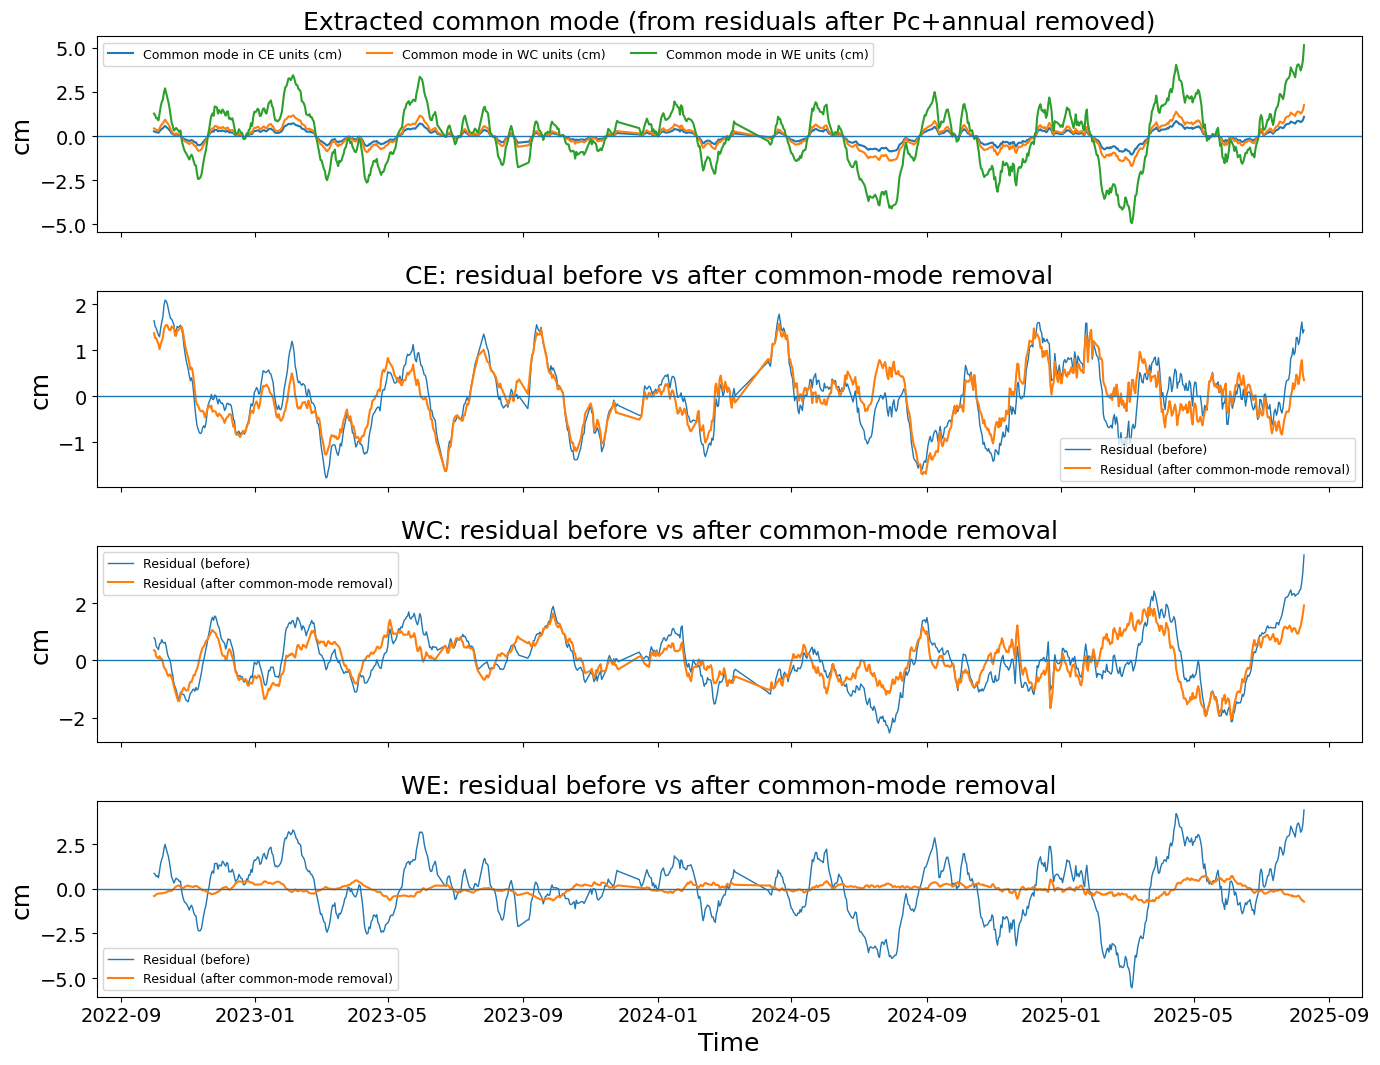

                                CE_MA_cm       WC_MA_cm       WE_MA_cm  \
2022-10-01 00:00:00+00:00  164208.878424  176563.181547  326019.241227   
2022-10-02 00:00:00+00:00  164208.764039  176563.121320  326019.164519   
2022-10-03 00:00:00+00:00  164208.739371  176562.878855  326019.046257   
2022-10-04 00:00:00+00:00  164208.689869  176562.827184  326019.082427   
2022-10-05 00:00:00+00:00  164208.640640  176562.768219  326018.979090   

                           CE_resid  WC_resid  WE_resid  CE_resid_clean  \
2022-10-01 00:00:00+00:00  1.637809  0.789513  0.863127        1.367454   
2022-10-02 00:00:00+00:00  1.514635  0.730246  0.801857        1.263940   
2022-10-03 00:00:00+00:00  1.474036  0.488256  0.691900        1.260117   
2022-10-04 00:00:00+00:00  1.401147  0.436540  0.728902        1.186531   
2022-10-05 00:00:00+00:00  1.324295  0.377372  0.622341        1.135807   

                           WC_resid_clean  WE_resid_clean  CE_common  \
2022-10-01 00:00:00+00:00       

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Files
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2*np.pi / T_YEAR

# -----------------------------
# Load helpers
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

def fit_nuisance(y, pc, t0):
    """
    Fit: y = a + b*Pc_z + c*sin(wt) + d*cos(wt)
    Return: yfit, resid, coeffs
    """
    Pc = pc.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    t_days = (y.index - t0).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([np.ones_like(Pc_z), Pc_z, sin_t, cos_t])
    x, *_ = np.linalg.lstsq(A, y.to_numpy(), rcond=None)
    yfit = A @ x
    resid = y.to_numpy() - yfit
    return yfit, resid, x  # a,b,c,d

# -----------------------------
# 1) Load & align
# -----------------------------
ce = load_baseline_daily_ma(CE_FILE, "CE")
wc = load_baseline_daily_ma(WC_FILE, "WC")
we = load_baseline_daily_ma(WE_FILE, "WE")
pc = load_pc_daily(PC_FILE)

df = pd.concat([ce, wc, we, pc], axis=1).dropna()
t = df.index
t0_common = t[0]  # shared origin so sin/cos phase is consistent

# -----------------------------
# 2) Remove nuisance per baseline
# -----------------------------
fits = {}
resid = {}
coeffs = {}

for name in ["CE", "WC", "WE"]:
    yfit, r, x = fit_nuisance(df[name], df["Pc_kPa"], t0_common)
    fits[name] = yfit
    resid[name] = r
    coeffs[name] = x

    a,b,c,d = x
    print(f"==== {name} nuisance coefficients (a,b,c,d) ====")
    print(f"a (intercept): {a:.6f}")
    print(f"b (Pc_z)     : {b:.6f}")
    print(f"c (sin)      : {c:.6f}")
    print(f"d (cos)      : {d:.6f}")
    print()

R = np.column_stack([resid["CE"], resid["WC"], resid["WE"]])  # (T x 3)

# -----------------------------
# 3) Extract and remove common mode via PCA/SVD
# -----------------------------
# Center each column (so PCA captures common variability, not offsets)
R_mean = R.mean(axis=0, keepdims=True)
R0 = R - R_mean

U, S, Vt = np.linalg.svd(R0, full_matrices=False)
pc1 = U[:, 0] * S[0]       # time series
loadings = Vt[0, :]        # per-baseline weights (unit vector)

# Reconstruction of the common mode (rank-1 approx)
R_common = np.outer(pc1, loadings)  # (T x 3)

# Remove common mode
R_clean = R0 - R_common

# Put back column means if you want (usually not needed for residuals)
R_clean = R_clean + R_mean

# Pack into dataframe
out = pd.DataFrame(index=t)
out["CE_MA_cm"] = df["CE"]
out["WC_MA_cm"] = df["WC"]
out["WE_MA_cm"] = df["WE"]

out["CE_resid"] = R[:,0]
out["WC_resid"] = R[:,1]
out["WE_resid"] = R[:,2]

out["CE_resid_clean"] = R_clean[:,0]
out["WC_resid_clean"] = R_clean[:,1]
out["WE_resid_clean"] = R_clean[:,2]

# Common mode time series expressed in each baseline’s units:
out["CE_common"] = R_common[:,0]
out["WC_common"] = R_common[:,1]
out["WE_common"] = R_common[:,2]

# Variance explained by common mode (PC1)
var_expl = (S[0]**2) / np.sum(S**2)
print(f"Common mode (PC1) variance explained in residuals: {100*var_expl:.1f}%")
print("Loadings [CE, WC, WE]:", loadings)

# -----------------------------
# 4) Plots
# -----------------------------
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(t, out["CE_common"], lw=1.5, label="Common mode in CE units (cm)")
axes[0].plot(t, out["WC_common"], lw=1.5, label="Common mode in WC units (cm)")
axes[0].plot(t, out["WE_common"], lw=1.5, label="Common mode in WE units (cm)")
axes[0].axhline(0, lw=1)
axes[0].set_ylabel("cm")
axes[0].set_title("Extracted common mode (from residuals after Pc+annual removed)")
axes[0].legend(ncol=3, fontsize=9)

for ax, name, col_before, col_after in [
    (axes[1], "CE", "CE_resid", "CE_resid_clean"),
    (axes[2], "WC", "WC_resid", "WC_resid_clean"),
    (axes[3], "WE", "WE_resid", "WE_resid_clean"),
]:
    ax.plot(t, out[col_before], lw=1.0, label="Residual (before)")
    ax.plot(t, out[col_after], lw=1.5, label="Residual (after common-mode removal)")
    ax.axhline(0, lw=1)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: residual before vs after common-mode removal")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Optional: corrected MA series (MA minus nuisance minus common, then add back mean)
# -----------------------------
# If you want a "deformation-only, common-mode-removed" series in MA units:
for name in ["CE","WC","WE"]:
    # MA minus nuisance fit = residual
    # residual minus common mode = resid_clean
    out[f"{name}_def_only_cm"] = out[f"{name}_resid_clean"]

print(out.head())


==== CE nuisance coefficients (a,b,c,d) ====
a (intercept): 164214.178488
b (Pc_z)     : -7.335868
c (sin)      : -0.393592
d (cos)      : 1.853800

==== WC nuisance coefficients (a,b,c,d) ====
a (intercept): 176562.090051
b (Pc_z)     : -0.826379
c (sin)      : -0.148387
d (cos)      : 1.292357

==== WE nuisance coefficients (a,b,c,d) ====
a (intercept): 326024.157858
b (Pc_z)     : -7.806333
c (sin)      : -1.846276
d (cos)      : 3.575744

Common mode (PC1) variance explained in residuals: 75.9%
Loadings [CE, WC, WE]: [-0.19679908 -0.31775724 -0.92752383] 



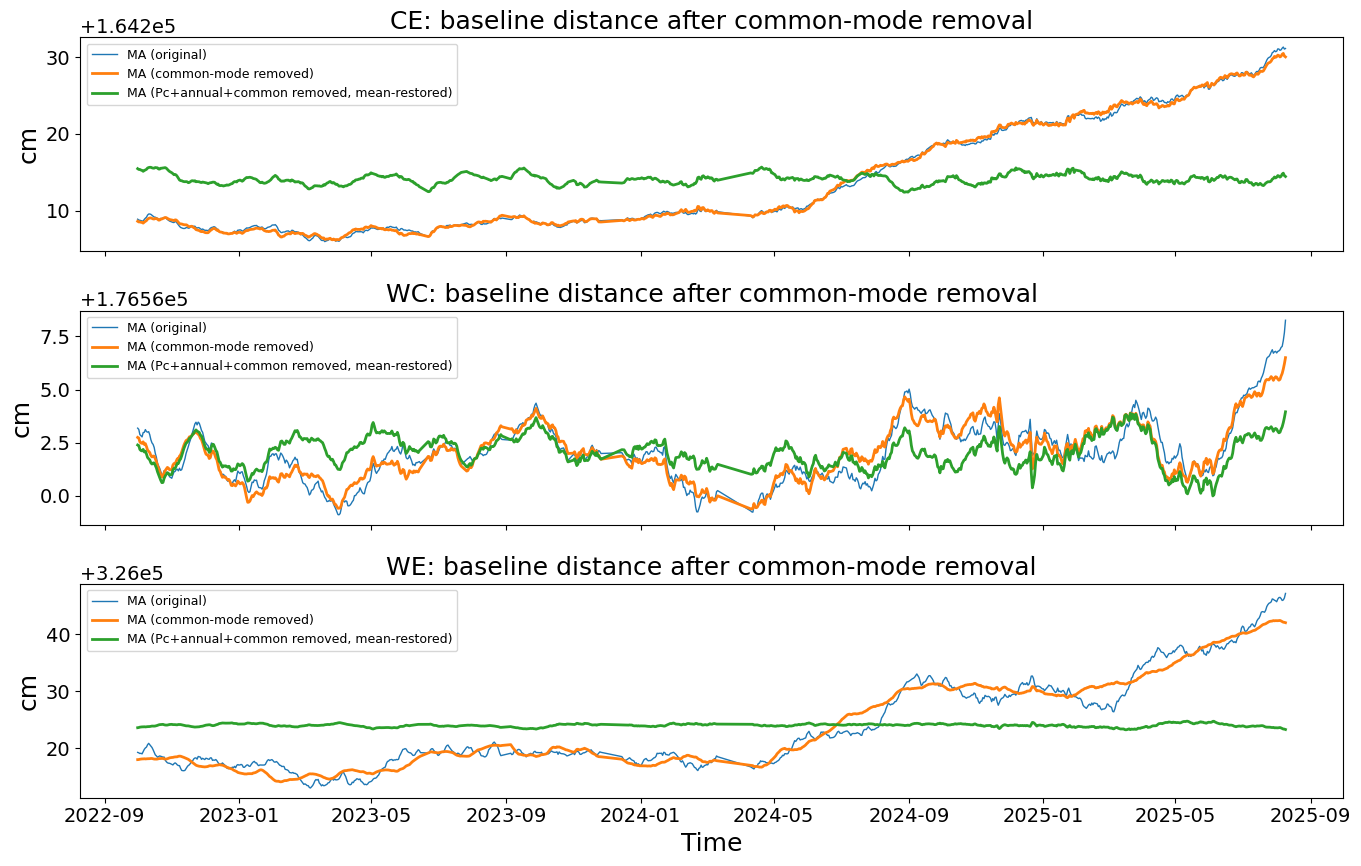

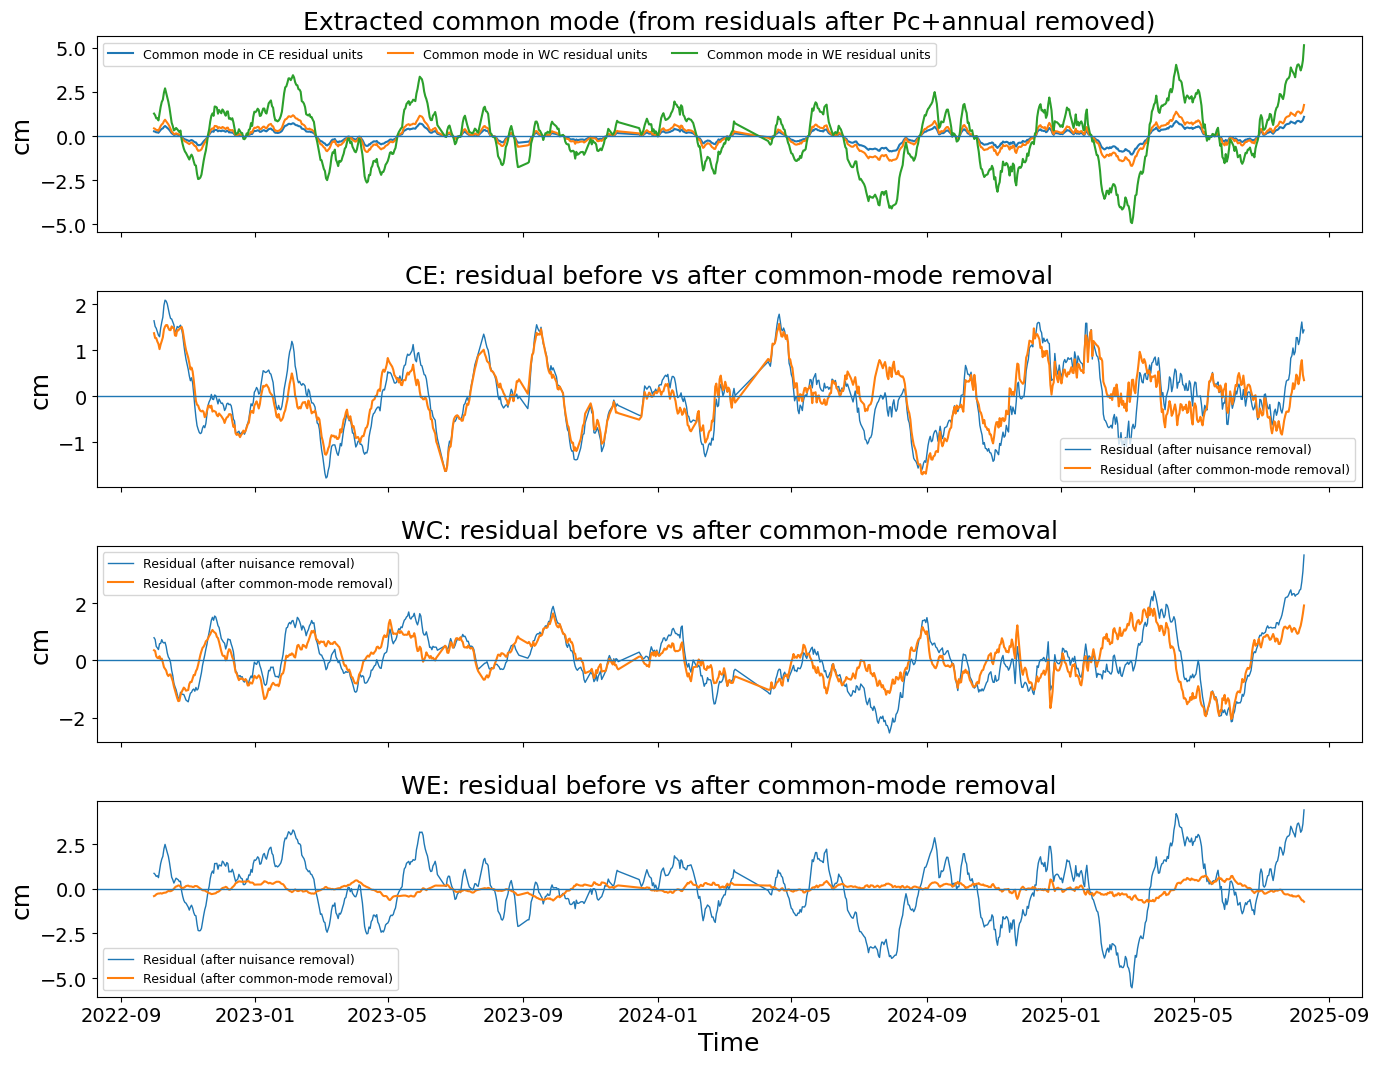

                                CE_MA_cm       WC_MA_cm       WE_MA_cm  \
2022-10-01 00:00:00+00:00  164208.878424  176563.181547  326019.241227   
2022-10-02 00:00:00+00:00  164208.764039  176563.121320  326019.164519   
2022-10-03 00:00:00+00:00  164208.739371  176562.878855  326019.046257   
2022-10-04 00:00:00+00:00  164208.689869  176562.827184  326019.082427   
2022-10-05 00:00:00+00:00  164208.640640  176562.768219  326018.979090   

                           CE_resid  WC_resid  WE_resid  CE_common  WC_common  \
2022-10-01 00:00:00+00:00  1.637809  0.789513  0.863127   0.270355   0.436523   
2022-10-02 00:00:00+00:00  1.514635  0.730246  0.801857   0.250695   0.404779   
2022-10-03 00:00:00+00:00  1.474036  0.488256  0.691900   0.213919   0.345399   
2022-10-04 00:00:00+00:00  1.401147  0.436540  0.728902   0.214616   0.346524   
2022-10-05 00:00:00+00:00  1.324295  0.377372  0.622341   0.188488   0.304338   

                           WE_common  CE_resid_clean  WC_resid_clean

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

DROP_DAYS = 30          # remove first month
T_YEAR = 365.25         # annual period (days)
W = 2.0 * np.pi / T_YEAR

# ============================================================
# LOADERS
# ============================================================
def load_baseline_daily_ma(path, name):
    """
    Returns daily series of the baseline 30-day Moving Average (cm),
    with first DROP_DAYS removed based on the baseline start time.
    """
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    """
    Returns daily Pc (kPa) series.
    """
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

# ============================================================
# NUISANCE FIT: y = a + b*Pc_z + c*sin + d*cos
# ============================================================
def fit_nuisance(y_series, pc_series, t0_common):
    """
    Fits y = a + b*Pc_z + c*sin(wt) + d*cos(wt)
    where Pc_z is z-scored over the aligned window.
    Returns:
      yfit (np.ndarray), resid (np.ndarray), coeffs (np.ndarray [a,b,c,d])
    """
    # z-score Pc
    Pc = pc_series.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    # seasonal terms on shared time origin
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([np.ones_like(Pc_z), Pc_z, sin_t, cos_t])
    y = y_series.to_numpy()

    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    yfit = A @ x
    resid = y - yfit
    return yfit, resid, x

# ============================================================
# MAIN
# ============================================================
# 1) Load daily MA series
ce = load_baseline_daily_ma(CE_FILE, "CE")
wc = load_baseline_daily_ma(WC_FILE, "WC")
we = load_baseline_daily_ma(WE_FILE, "WE")

# 2) Load daily Pc
pc = load_pc_daily(PC_FILE)

# 3) Align everything to common daily window
df = pd.concat([ce, wc, we, pc], axis=1).dropna()
t = df.index
t0_common = t[0]  # fixed origin so sin/cos phase is identical across baselines

# 4) Fit nuisance per baseline and compute residuals
fits = {}
resid = {}
coeffs = {}

for name in ["CE", "WC", "WE"]:
    yfit, r, x = fit_nuisance(df[name], df["Pc_kPa"], t0_common)
    fits[name] = yfit
    resid[name] = r
    coeffs[name] = x

    a, b, c, d = x
    print(f"==== {name} nuisance coefficients (a,b,c,d) ====")
    print(f"a (intercept): {a:.6f}")
    print(f"b (Pc_z)     : {b:.6f}")
    print(f"c (sin)      : {c:.6f}")
    print(f"d (cos)      : {d:.6f}\n")

# Residual matrix: (T x 3) in order [CE, WC, WE]
R = np.column_stack([resid["CE"], resid["WC"], resid["WE"]])

# 5) Extract common mode from residuals using SVD (rank-1 approximation)
#    Center each baseline residual first
R_mean = R.mean(axis=0, keepdims=True)
R0 = R - R_mean

U, S, Vt = np.linalg.svd(R0, full_matrices=False)
pc1 = U[:, 0] * S[0]       # time series
loadings = Vt[0, :]        # per-baseline weights (unit vector)

# Common-mode reconstruction
R_common = np.outer(pc1, loadings)  # (T x 3)

# Remove common mode (then add means back)
R_clean0 = R0 - R_common
R_clean = R_clean0 + R_mean

var_expl = (S[0]**2) / np.sum(S**2)

print(f"Common mode (PC1) variance explained in residuals: {100*var_expl:.1f}%")
print("Loadings [CE, WC, WE]:", loadings, "\n")

# 6) Build output dataframe with baseline MA before/after
out = pd.DataFrame(index=t)
out["CE_MA_cm"] = df["CE"]
out["WC_MA_cm"] = df["WC"]
out["WE_MA_cm"] = df["WE"]

# residuals (after nuisance removal)
out["CE_resid"] = R[:, 0]
out["WC_resid"] = R[:, 1]
out["WE_resid"] = R[:, 2]

# common mode in each baseline's residual units
out["CE_common"] = R_common[:, 0]
out["WC_common"] = R_common[:, 1]
out["WE_common"] = R_common[:, 2]

# residuals after common-mode removal
out["CE_resid_clean"] = R_clean[:, 0]
out["WC_resid_clean"] = R_clean[:, 1]
out["WE_resid_clean"] = R_clean[:, 2]

# ---- What you asked for: baseline distance AFTER common-mode removal ----
# Since common mode was estimated in residual space, remove it from the MA like:
# MA_common_removed = MA - common_mode_residual_component
for name in ["CE", "WC", "WE"]:
    out[f"{name}_MA_common_removed"] = out[f"{name}_MA_cm"] - out[f"{name}_common"]

# Also provide a "deformation-only" (nuisance+common removed) series in absolute cm scale:
# def_only = resid_clean; add back mean(MA) just to keep absolute-like scale
for name in ["CE", "WC", "WE"]:
    out[f"{name}_MA_nuis_common_removed"] = out[f"{name}_resid_clean"] + out[f"{name}_MA_cm"].mean()

# ============================================================
# PLOTS
# ============================================================

# Plot 1: Baseline MA before/after common-mode removal
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, name in zip(axes, ["CE", "WC", "WE"]):
    ax.plot(out.index, out[f"{name}_MA_cm"], lw=1.0, label="MA (original)")
    ax.plot(out.index, out[f"{name}_MA_common_removed"], lw=2.0, label="MA (common-mode removed)")
    ax.plot(out.index, out[f"{name}_MA_nuis_common_removed"], lw=2.0,
            label="MA (Pc+annual+common removed, mean-restored)")
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: baseline distance after common-mode removal")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Plot 2: Residuals before/after common-mode removal + common mode
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(out.index, out["CE_common"], lw=1.5, label="Common mode in CE residual units")
axes[0].plot(out.index, out["WC_common"], lw=1.5, label="Common mode in WC residual units")
axes[0].plot(out.index, out["WE_common"], lw=1.5, label="Common mode in WE residual units")
axes[0].axhline(0, lw=1)
axes[0].set_ylabel("cm")
axes[0].set_title("Extracted common mode (from residuals after Pc+annual removed)")
axes[0].legend(ncol=3, fontsize=9)

for ax, name in zip(axes[1:], ["CE", "WC", "WE"]):
    ax.plot(out.index, out[f"{name}_resid"], lw=1.0, label="Residual (after nuisance removal)")
    ax.plot(out.index, out[f"{name}_resid_clean"], lw=1.5, label="Residual (after common-mode removal)")
    ax.axhline(0, lw=1)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: residual before vs after common-mode removal")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# ============================================================
# OPTIONAL: save the outputs
# ============================================================
# out.to_csv("/mnt/data/common_mode_removed_outputs.csv")
# print("Saved:", "/mnt/data/common_mode_removed_outputs.csv")


==== CE season-only coefficients ====
a (intercept): 164213.767040
c (sin)      : -1.738177
d (cos)      : -0.290970
Season amp A : 1.762363 cm   (peak-to-trough 3.524726 cm)

==== WC season-only coefficients ====
a (intercept): 176562.035487
c (sin)      : -0.282465
d (cos)      : 1.085433
Season amp A : 1.121584 cm   (peak-to-trough 2.243168 cm)

==== WE season-only coefficients ====
a (intercept): 326023.723839
c (sin)      : -3.194084
d (cos)      : 1.290011
Season amp A : 3.444750 cm   (peak-to-trough 6.889500 cm)

Common mode (PC1) variance explained after season removal: 98.3%
Loadings [CE, WC, WE]: [0.67474621 0.08244925 0.73343007] 



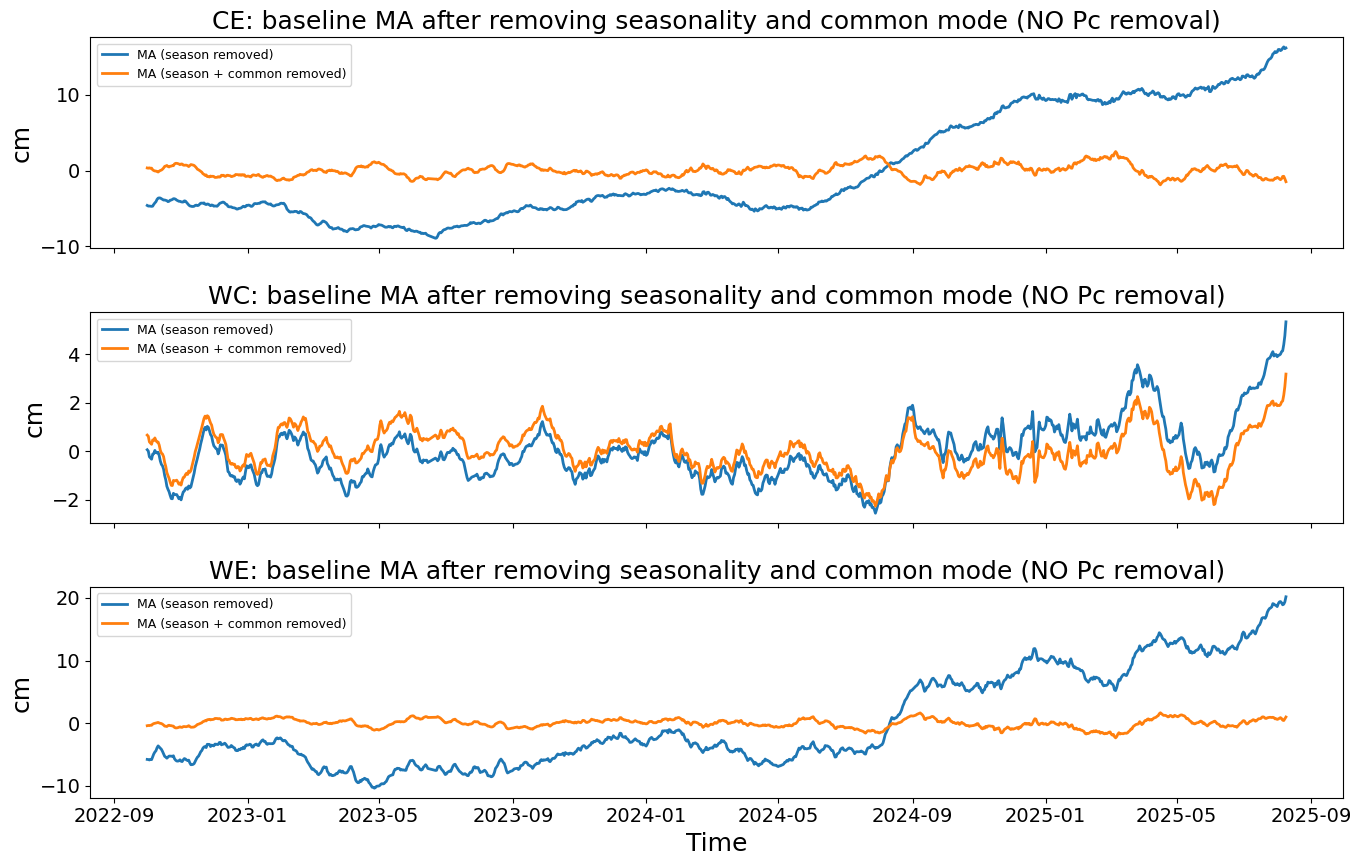

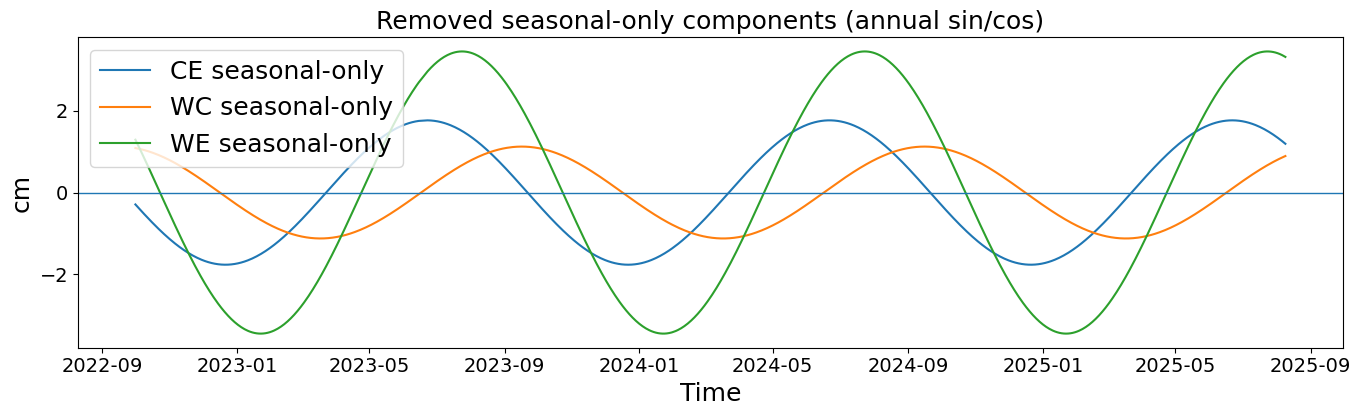

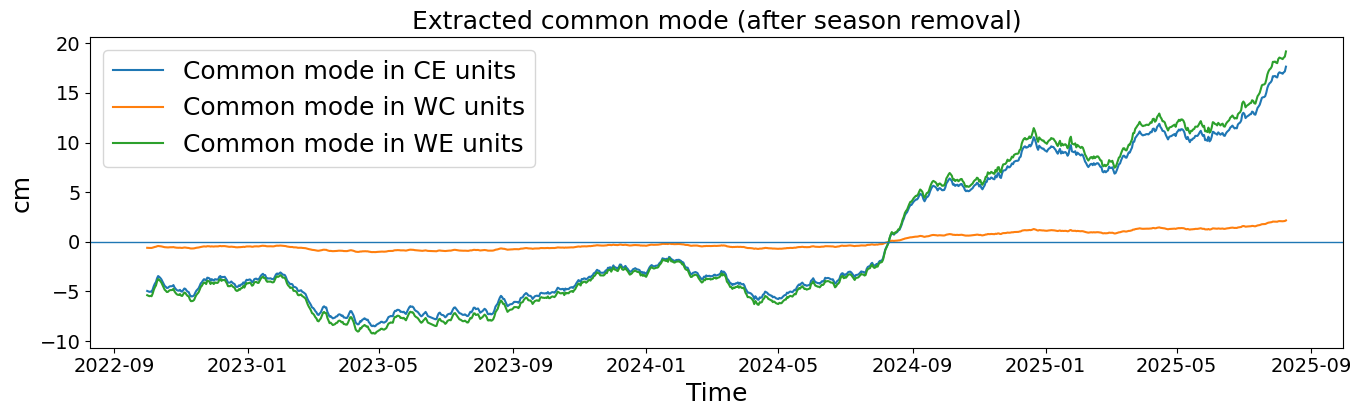

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"
DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR

# ============================================================
# LOADERS
# ============================================================
def load_baseline_daily_ma(path, name):
    """
    Daily series of the baseline 30-day Moving Average (cm),
    with first DROP_DAYS removed based on baseline start time.
    """
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

# ============================================================
# SEASONAL FIT: y = a + c*sin + d*cos  (NO Pc TERM)
# ============================================================
def fit_season_only(y_series, t0_common):
    """
    Fit y = a + c*sin(wt) + d*cos(wt)
    Returns:
      yfit, resid, coeffs [a,c,d]
    """
    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([np.ones_like(t_days), sin_t, cos_t])
    y = y_series.to_numpy()

    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    yfit = A @ x
    resid = y - yfit
    return yfit, resid, x  # a,c,d

# ============================================================
# MAIN
# ============================================================
# 1) Load daily MA series
ce = load_baseline_daily_ma(CE_FILE, "CE")
wc = load_baseline_daily_ma(WC_FILE, "WC")
we = load_baseline_daily_ma(WE_FILE, "WE")

# 2) Align to common daily window
df = pd.concat([ce, wc, we], axis=1).dropna()
t = df.index
t0_common = t[0]  # shared origin => consistent sin/cos phase

# 3) Remove seasonality (no Pc)
season_fit = {}
season_resid = {}
season_coeffs = {}

for name in ["CE", "WC", "WE"]:
    yfit, resid, x = fit_season_only(df[name], t0_common)
    season_fit[name] = yfit          # includes intercept + seasonal
    season_resid[name] = resid       # MA with season removed
    season_coeffs[name] = x

    a, c, d = x
    amp = np.sqrt(c*c + d*d)
    print(f"==== {name} season-only coefficients ====")
    print(f"a (intercept): {a:.6f}")
    print(f"c (sin)      : {c:.6f}")
    print(f"d (cos)      : {d:.6f}")
    print(f"Season amp A : {amp:.6f} cm   (peak-to-trough {2*amp:.6f} cm)\n")

# Residual matrix after removing seasonality: (T x 3) order [CE, WC, WE]
R = np.column_stack([season_resid["CE"], season_resid["WC"], season_resid["WE"]])

# 4) Extract and remove common mode from the season-removed residuals
R_mean = R.mean(axis=0, keepdims=True)
R0 = R - R_mean

U, S, Vt = np.linalg.svd(R0, full_matrices=False)
pc1 = U[:, 0] * S[0]
loadings = Vt[0, :]

R_common = np.outer(pc1, loadings)   # common mode in each baseline's units
R_clean0 = R0 - R_common
R_clean = R_clean0 + R_mean

var_expl = (S[0]**2) / np.sum(S**2)
print(f"Common mode (PC1) variance explained after season removal: {100*var_expl:.1f}%")
print("Loadings [CE, WC, WE]:", loadings, "\n")

# 5) Build output dataframe (this time: no Pc removal anywhere)
out = pd.DataFrame(index=t)
out["CE_MA_cm"] = df["CE"]
out["WC_MA_cm"] = df["WC"]
out["WE_MA_cm"] = df["WE"]

# seasonal component only (y - a)
for name in ["CE", "WC", "WE"]:
    a, c, d = season_coeffs[name]
    t_days = (t - t0_common).total_seconds() / 86400.0
    out[f"{name}_season_only"] = c*np.sin(W*t_days) + d*np.cos(W*t_days)

# MA after removing seasonality (still includes Pc etc., by design)
out["CE_season_removed"] = season_resid["CE"]
out["WC_season_removed"] = season_resid["WC"]
out["WE_season_removed"] = season_resid["WE"]

# common mode contributions (estimated from season-removed residual space)
out["CE_common"] = R_common[:, 0]
out["WC_common"] = R_common[:, 1]
out["WE_common"] = R_common[:, 2]

# final: MA after removing seasonality AND common mode
out["CE_season_common_removed"] = out["CE_season_removed"] - out["CE_common"]
out["WC_season_common_removed"] = out["WC_season_removed"] - out["WC_common"]
out["WE_season_common_removed"] = out["WE_season_removed"] - out["WE_common"]

# ============================================================
# PLOTS
# ============================================================

# Plot A: original MA vs season-removed vs season+common removed
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, name in zip(axes, ["CE", "WC", "WE"]):
    #ax.plot(out.index, out[f"{name}_MA_cm"], lw=1.0, label="MA (original)")
    ax.plot(out.index, out[f"{name}_season_removed"], lw=2.0, label="MA (season removed)")
    ax.plot(out.index, out[f"{name}_season_common_removed"], lw=2.0, label="MA (season + common removed)")
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: baseline MA after removing seasonality and common mode (NO Pc removal)")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Plot B: seasonal-only terms overlaid (to see what was removed)
plt.figure(figsize=(14, 4.5))
for name in ["CE", "WC", "WE"]:
    plt.plot(out.index, out[f"{name}_season_only"], lw=1.5, label=f"{name} seasonal-only")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Removed seasonal-only components (annual sin/cos)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot C: common mode in each baseline (estimated after season removal)
plt.figure(figsize=(14, 4.5))
plt.plot(out.index, out["CE_common"], lw=1.5, label="Common mode in CE units")
plt.plot(out.index, out["WC_common"], lw=1.5, label="Common mode in WC units")
plt.plot(out.index, out["WE_common"], lw=1.5, label="Common mode in WE units")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Extracted common mode (after season removal)")
plt.legend()
plt.tight_layout()
plt.show()

==== CE fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 164214.178488
b (Pc_z)     : -7.335868
c (sin)      : -0.393592
d (cos)      : 1.853800
Season amp A : 1.895122 cm   (peak-to-trough 3.790245 cm)

==== WC fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 176562.090051
b (Pc_z)     : -0.826379
c (sin)      : -0.148387
d (cos)      : 1.292357
Season amp A : 1.300848 cm   (peak-to-trough 2.601696 cm)

==== WE fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 326024.157858
b (Pc_z)     : -7.806333
c (sin)      : -1.846276
d (cos)      : 3.575744
Season amp A : 4.024262 cm   (peak-to-trough 8.048523 cm)

Common mode (PC1) variance explained after seasonal removal: 98.4%
Loadings [CE, WC, WE]: [0.67501566 0.08176341 0.73325889] 



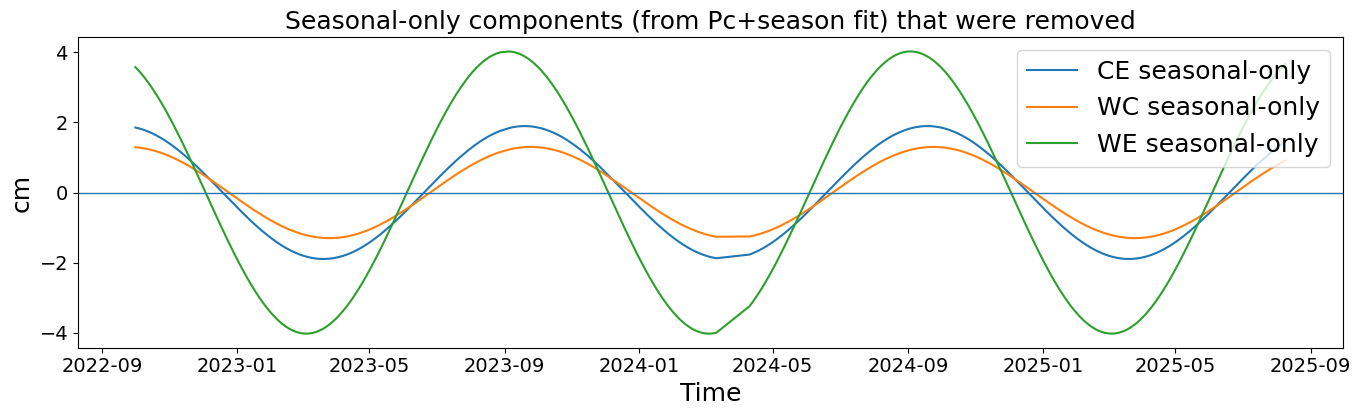

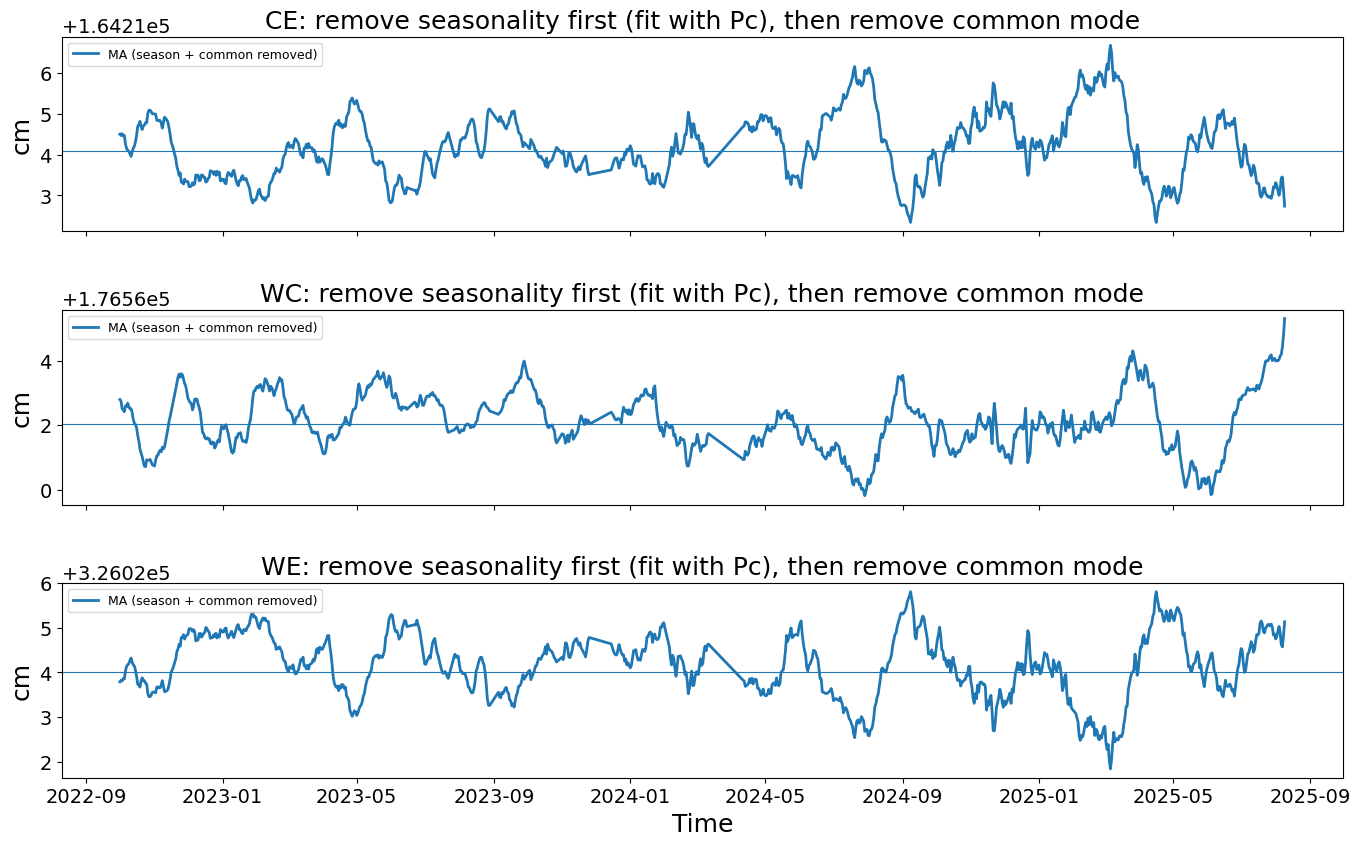

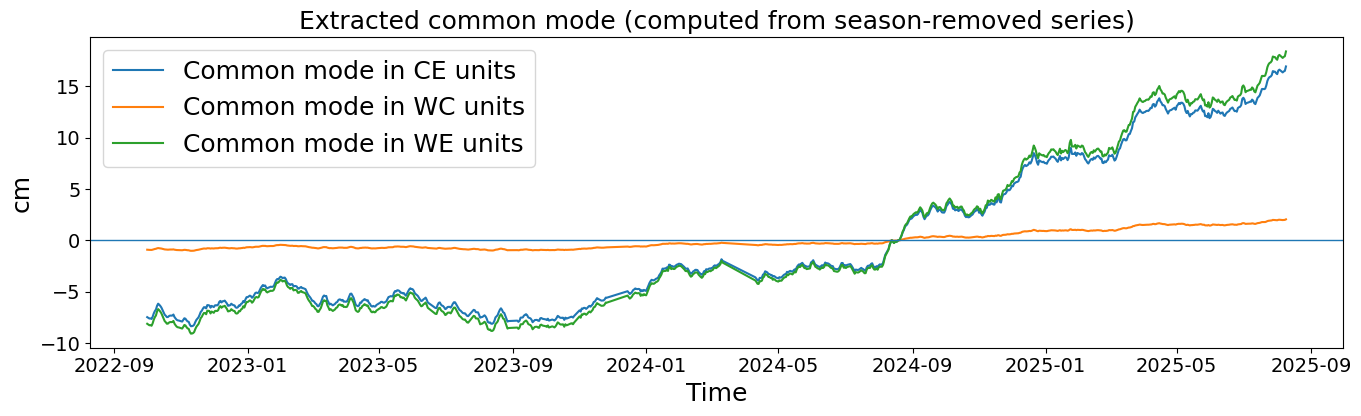

                             Pc_kPa       CE_MA_cm  CE_season_only  \
2022-10-01 00:00:00+00:00  1.347564  164208.878424        1.853800   
2022-10-02 00:00:00+00:00  1.345193  164208.764039        1.846755   
2022-10-03 00:00:00+00:00  1.341670  164208.739371        1.839164   
2022-10-04 00:00:00+00:00  1.336950  164208.689869        1.831029   
2022-10-05 00:00:00+00:00  1.331513  164208.640640        1.822351   

                           CE_season_removed       WC_MA_cm  WC_season_only  \
2022-10-01 00:00:00+00:00      164207.024624  176563.181547        1.292357   
2022-10-02 00:00:00+00:00      164206.917284  176563.121320        1.289613   
2022-10-03 00:00:00+00:00      164206.900208  176562.878855        1.286488   
2022-10-04 00:00:00+00:00      164206.858840  176562.827184        1.282982   
2022-10-05 00:00:00+00:00      164206.818289  176562.768219        1.279096   

                           WC_season_removed       WE_MA_cm  WE_season_only  \
2022-10-01 00:00:00+00:00

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GOAL
#   1) Fit each baseline MA with:  y = a + b*Pc_z + c*sin + d*cos
#   2) Remove ONLY the seasonal part:  S(t)=c*sin + d*cos
#      (Pc effect is NOT removed)
#   3) From the season-removed series, find a common mode (SVD/PCA)
#   4) Remove that common mode from each baseline
# ============================================================

# -----------------------------
# Files
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR

# -----------------------------
# Loaders
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

# -----------------------------
# Fit: y = a + b*Pc_z + c*sin + d*cos
# Return seasonal-only S(t)=c*sin+d*cos and coeffs
# -----------------------------
def fit_pc_plus_season_and_get_season(y_series, pc_series, t0_common):
    Pc = pc_series.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([np.ones_like(Pc_z), Pc_z, sin_t, cos_t])
    y = y_series.to_numpy()

    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c, d = x

    season_only = c * sin_t + d * cos_t
    amp = float(np.sqrt(c*c + d*d))
    return season_only, (a, b, c, d), amp

# ============================================================
# MAIN
# ============================================================

# 1) Load daily MA series + Pc
ce = load_baseline_daily_ma(CE_FILE, "CE")
wc = load_baseline_daily_ma(WC_FILE, "WC")
we = load_baseline_daily_ma(WE_FILE, "WE")
pc = load_pc_daily(PC_FILE)

# 2) Align to common daily window
df = pd.concat([ce, wc, we, pc], axis=1).dropna()
t = df.index
t0_common = t[0]  # fixed origin -> consistent seasonal phase

# 3) For each baseline: fit Pc+season, then remove ONLY season
out = pd.DataFrame(index=t)
out["Pc_kPa"] = df["Pc_kPa"]

for name in ["CE", "WC", "WE"]:
    out[f"{name}_MA_cm"] = df[name]

    season_only, (a, b, c, d), amp = fit_pc_plus_season_and_get_season(df[name], df["Pc_kPa"], t0_common)
    out[f"{name}_season_only"] = season_only
    out[f"{name}_season_removed"] = df[name].to_numpy() - season_only  # Pc not removed

    print(f"==== {name} fit y = a + b*Pc_z + c*sin + d*cos ====")
    print(f"a (intercept): {a:.6f}")
    print(f"b (Pc_z)     : {b:.6f}")
    print(f"c (sin)      : {c:.6f}")
    print(f"d (cos)      : {d:.6f}")
    print(f"Season amp A : {amp:.6f} cm   (peak-to-trough {2*amp:.6f} cm)\n")

# 4) Find common mode from the season-removed series
R = np.column_stack([
    out["CE_season_removed"].to_numpy(),
    out["WC_season_removed"].to_numpy(),
    out["WE_season_removed"].to_numpy()
])  # (T x 3)

# center columns for PCA/SVD
R_mean = R.mean(axis=0, keepdims=True)
R0 = R - R_mean

U, S, Vt = np.linalg.svd(R0, full_matrices=False)
pc1 = U[:, 0] * S[0]
loadings = Vt[0, :]

R_common = np.outer(pc1, loadings)   # common mode contribution in each baseline's units
R_clean0 = R0 - R_common
R_clean = R_clean0 + R_mean

var_expl = (S[0]**2) / np.sum(S**2)
print(f"Common mode (PC1) variance explained after seasonal removal: {100*var_expl:.1f}%")
print("Loadings [CE, WC, WE]:", loadings, "\n")

# Store common mode + cleaned series
out["CE_common"] = R_common[:, 0]
out["WC_common"] = R_common[:, 1]
out["WE_common"] = R_common[:, 2]

out["CE_season_common_removed"] = out["CE_season_removed"] - out["CE_common"]
out["WC_season_common_removed"] = out["WC_season_removed"] - out["WC_common"]
out["WE_season_common_removed"] = out["WE_season_removed"] - out["WE_common"]

# ============================================================
# PLOTS
# ============================================================

# Plot 1: seasonal-only terms removed (so you can see they are "similar")
plt.figure(figsize=(14, 4.5))
for name in ["CE", "WC", "WE"]:
    plt.plot(out.index, out[f"{name}_season_only"], lw=1.5, label=f"{name} seasonal-only")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Seasonal-only components (from Pc+season fit) that were removed")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: baseline MA vs season-removed vs season+common removed
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, name in zip(axes, ["CE", "WC", "WE"]):
    #ax.plot(out.index, out[f"{name}_MA_cm"], lw=1.0, label="MA (original)")
    #ax.plot(out.index, out[f"{name}_season_removed"], lw=2.0, label="MA (season removed; Pc kept)")
    ax.plot(out.index, out[f"{name}_season_common_removed"], lw=2.0, label="MA (season + common removed)")
    ax.axhline(out[f"{name}_MA_cm"].mean(), lw=0.8)  # visual reference (mean)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: remove seasonality first (fit with Pc), then remove common mode")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Plot 3: common mode in each baseline (estimated after season removal)
plt.figure(figsize=(14, 4.5))
plt.plot(out.index, out["CE_common"], lw=1.5, label="Common mode in CE units")
plt.plot(out.index, out["WC_common"], lw=1.5, label="Common mode in WC units")
plt.plot(out.index, out["WE_common"], lw=1.5, label="Common mode in WE units")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Extracted common mode (computed from season-removed series)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# OPTIONAL SAVE
# ============================================================
# out.to_csv("/mnt/data/season_then_common_removed.csv")
# print("Saved:", "/mnt/data/season_then_common_removed.csv")

print(out.head())


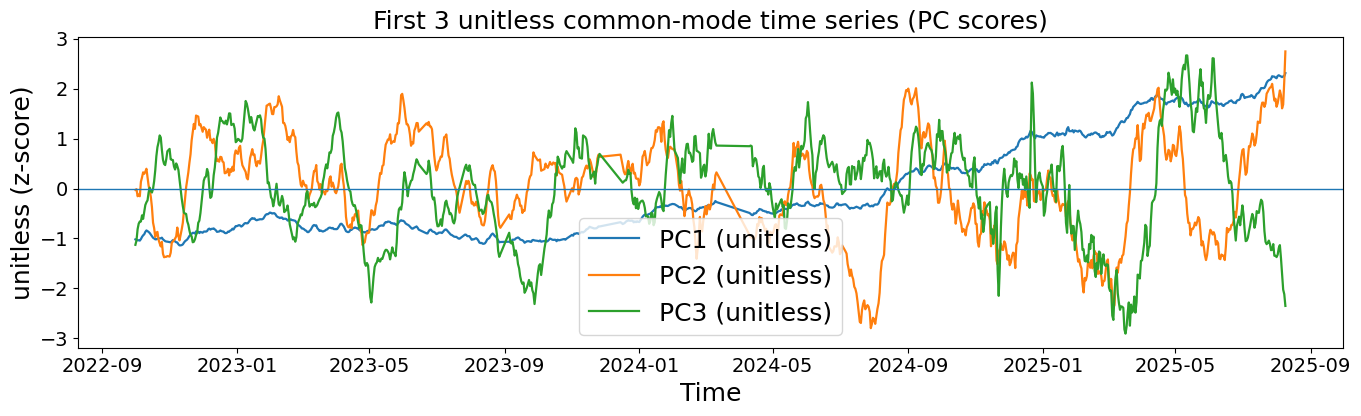

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# build matrix from your season-removed series (T x 3)
R = np.column_stack([
    out["CE_season_removed"].to_numpy(),
    out["WC_season_removed"].to_numpy(),
    out["WE_season_removed"].to_numpy()
])

# center columns (PCA convention)
R0 = R - R.mean(axis=0, keepdims=True)

# SVD / PCA
U, S, Vt = np.linalg.svd(R0, full_matrices=False)

# unitless (z-scored) common modes = first 3 PC time series
pcs_unitless = []
for k in range(3):
    pc = U[:, k] * S[k]                  # PC score (same units as data)
    pc_u = (pc - pc.mean()) / pc.std()   # unitless
    pcs_unitless.append(pc_u)

# plot
plt.figure(figsize=(14,4.5))
for k, pc_u in enumerate(pcs_unitless, start=1):
    plt.plot(out.index, pc_u, lw=1.6, label=f"PC{k} (unitless)")
plt.axhline(0, lw=1)
plt.ylabel("unitless (z-score)")
plt.xlabel("Time")
plt.title("First 3 unitless common-mode time series (PC scores)")
plt.legend()
plt.tight_layout()
plt.show()


PC1 variance explained (raw centered MA): 97.2%
Loadings [CE, WC, WE]: [0.66142673 0.08557504 0.7451118 ]


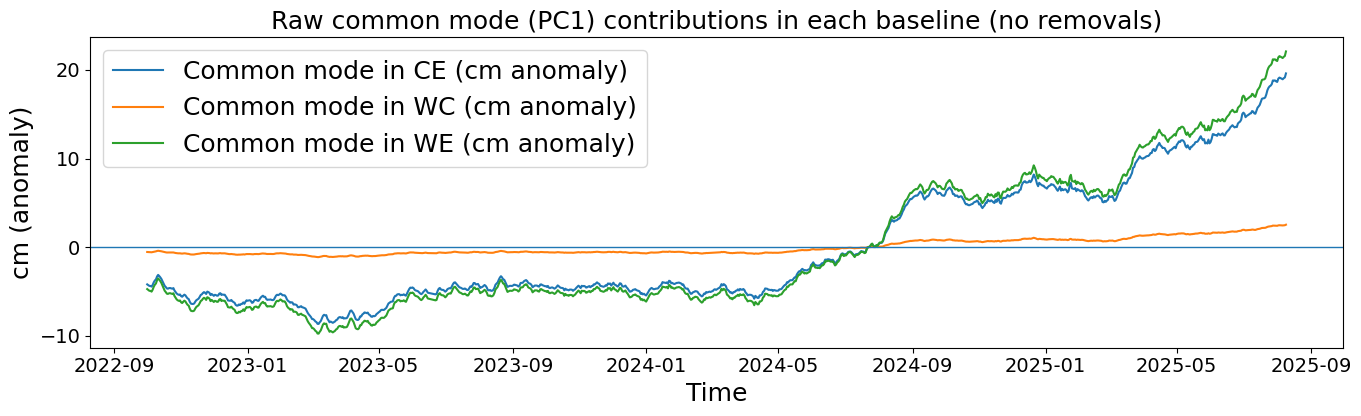

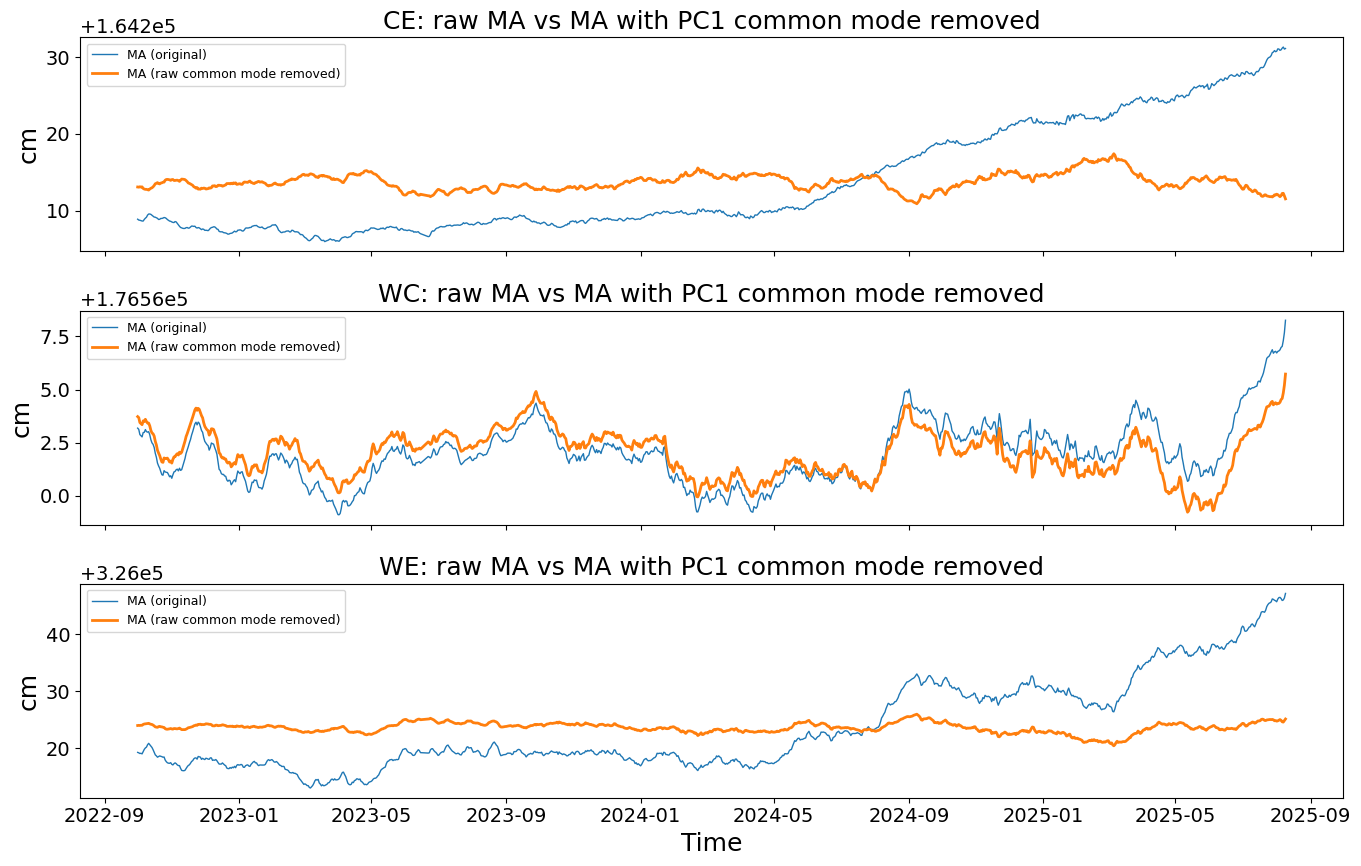

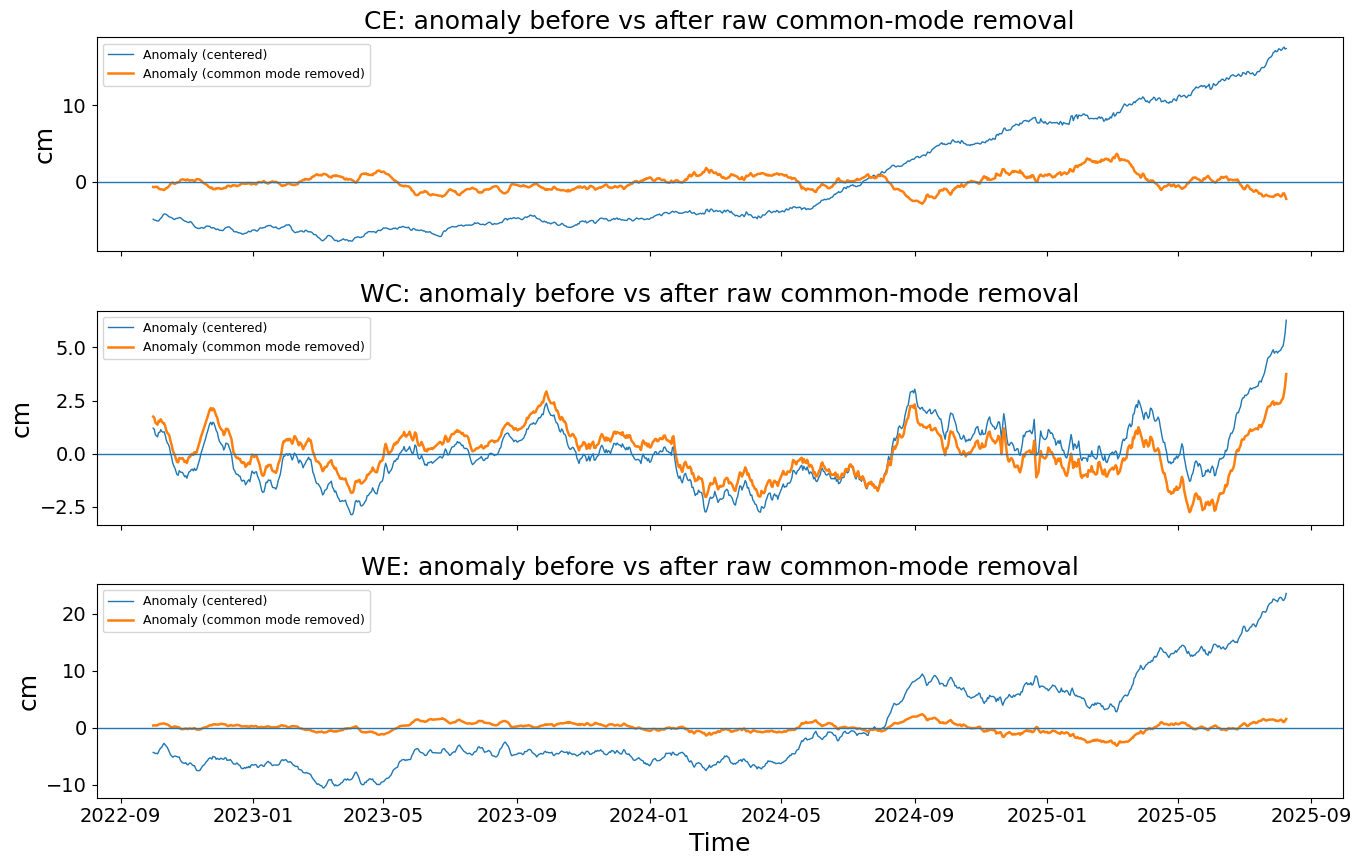

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Common mode from RAW baseline MA (centered), no removals
# Case 2: center each baseline, then SVD/PCA
# ============================================================

CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
DROP_DAYS = 30

def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    # drop first 30 days from baseline start
    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

# 1) Load and align
ce = load_baseline_daily_ma(CE_FILE, "CE")
wc = load_baseline_daily_ma(WC_FILE, "WC")
we = load_baseline_daily_ma(WE_FILE, "WE")

df = pd.concat([ce, wc, we], axis=1).dropna()
t = df.index

Y = df[["CE", "WC", "WE"]].to_numpy()  # (T x 3)

# 2) Center each baseline (column)
col_mean = Y.mean(axis=0, keepdims=True)
Y0 = Y - col_mean

# 3) SVD for PC1 common mode
U, S, Vt = np.linalg.svd(Y0, full_matrices=False)

pc1 = U[:, 0] * S[0]      # time series (arbitrary scaling)
loadings = Vt[0, :]       # weights for [CE, WC, WE]
var_expl = (S[0]**2) / np.sum(S**2)

print(f"PC1 variance explained (raw centered MA): {100*var_expl:.1f}%")
print("Loadings [CE, WC, WE]:", loadings)

# 4) Reconstruct common mode contribution in each baseline's units
Y_common = np.outer(pc1, loadings)     # (T x 3)
Y_clean = Y0 - Y_common               # centered data with common mode removed

# 5) Pack results
out = pd.DataFrame(index=t)
out["CE_MA_cm"] = df["CE"]
out["WC_MA_cm"] = df["WC"]
out["WE_MA_cm"] = df["WE"]

# common mode contribution (in cm anomaly units, since we centered)
out["CE_common"] = Y_common[:, 0]
out["WC_common"] = Y_common[:, 1]
out["WE_common"] = Y_common[:, 2]

# baseline anomalies (centered)
out["CE_anom"] = Y0[:, 0]
out["WC_anom"] = Y0[:, 1]
out["WE_anom"] = Y0[:, 2]

# anomalies after removing the common mode
out["CE_anom_clean"] = Y_clean[:, 0]
out["WC_anom_clean"] = Y_clean[:, 1]
out["WE_anom_clean"] = Y_clean[:, 2]

# If you want "absolute-like" series after common-mode removal, add back each baseline mean
out["CE_MA_common_removed"] = out["CE_anom_clean"] + col_mean[0, 0]
out["WC_MA_common_removed"] = out["WC_anom_clean"] + col_mean[0, 1]
out["WE_MA_common_removed"] = out["WE_anom_clean"] + col_mean[0, 2]

# ============================================================
# PLOTS
# ============================================================

# Plot A: common mode contributions overlaid (anomaly units)
plt.figure(figsize=(14, 4.5))
plt.plot(out.index, out["CE_common"], lw=1.5, label="Common mode in CE (cm anomaly)")
plt.plot(out.index, out["WC_common"], lw=1.5, label="Common mode in WC (cm anomaly)")
plt.plot(out.index, out["WE_common"], lw=1.5, label="Common mode in WE (cm anomaly)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm (anomaly)")
plt.title("Raw common mode (PC1) contributions in each baseline (no removals)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot B: baseline MA before vs after raw common-mode removal
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, name in zip(axes, ["CE", "WC", "WE"]):
    ax.plot(out.index, out[f"{name}_MA_cm"], lw=1.0, label="MA (original)")
    ax.plot(out.index, out[f"{name}_MA_common_removed"], lw=2.0, label="MA (raw common mode removed)")
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: raw MA vs MA with PC1 common mode removed")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Plot C: anomalies before vs after common-mode removal
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, name in zip(axes, ["CE", "WC", "WE"]):
    ax.plot(out.index, out[f"{name}_anom"], lw=1.0, label="Anomaly (centered)")
    ax.plot(out.index, out[f"{name}_anom_clean"], lw=1.8, label="Anomaly (common mode removed)")
    ax.axhline(0, lw=1)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: anomaly before vs after raw common-mode removal")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

